# Post Pandemic Regime Shifts in Labor Market: Exploratory Data Analysis

## Purpose
### Problem Statement
### Objective
### Scope and Limitations

## Research Context

## Imports and Configuration

In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from scipy import stats
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller

from regime_shift.config import (
    BREAK_PATH,
    CURVE_PATH,
    EDA_PATH,
    FIG_ROOT,
    FIG_SIZE,
    FIG_TALL,
    FIG_WIDE,
    MERGED_PATH,
    PLOT_STYLE,
    POST_LABEL,
    PRE_LABEL,
    REGIME_DATES,
    REGIME_PATH,
    REPORT_ROOT,
    ROLL_PATH,
    SAVE_DPI,
    SHOCK_LABEL,
    SHOW_DEC,
    STAT_ALPHA,
    UNIT_PATH,
)
from regime_shift.preprocessing import missing_data, set_date

warnings.filterwarnings("ignore")

project_root = Path.cwd().resolve()
src_root = project_root / "src"

sys.path.insert(0, str(src_root))

FIG_ROOT.mkdir(parents=True, exist_ok=True)
REPORT_ROOT.mkdir(parents=True, exist_ok=True)

plt.style.use(PLOT_STYLE)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Load Dataset

In [2]:
df = pd.read_csv(MERGED_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Data Shape: {df.shape}")
print(f"Date Range: {df['date'].min().date()} to {df['date'].max().date()}")

Data Shape: (316, 135)
Date Range: 2000-01-01 to 2026-04-01


## Data Overview

In [3]:
df.head(3)

,date,job_openings_level,hires_rate,hires_level,quits_rate,quits_level,total_separations_rate,total_separations_level,layoffs_discharges_level,layoffs_discharges_rate,unemployment_rate,unemployment_level,u6_rate,prime_age_lfpr,lfpr,epop_ratio,prime_age_urate,avg_weeks_unemployed,payrolls_nonfarm,payrolls_private,payrolls_manufacturing,payrolls_services,payrolls_construction,ahe_private,awe_private,awh_private,awe_manufacturing,ahe_manufacturing,eci_total,eci_wages,cpi_all,cpi_core,cpi_less_shelter,cpi_services_less_rent,cpi_services_less_energy,cpi_shelter,cpi_medical,cpi_food,pce_price,pce_core,pce_trimmed_12m,pce_trimmed_1m,pce_services,saving_rate,real_dpi,real_pi,real_pi_less_transfers,retail_advance,real_retail,ip_total,ip_manufacturing,capacity_util,housing_starts,building_permits,new_home_sales,consumer_sentiment,durable_orders,capex_orders,ci_loans,bank_credit,m2,treasury_1m,treasury_3m,treasury_2y,treasury_10y,fed_funds,aaa_yield,baa_yield,hy_oas,bbb_oas,breakeven_5y,breakeven_10y,forward_5y5y,michigan_1y,kcfed_lmci_activity,kcfed_lmci_momentum,recession,output_per_hour,unit_labor_costs,atl_.,atl_..1,atl_..2,atl_..3,atl_..4,atl_..5,atl_..6,atl_..7,atl_..8,atl_..9,atl_..10,atl_..11,atl_..12,atl_..13,atl_..14,atl_..15,phl_ruc_RUC15Q1,phl_ruc_RUC15Q2,phl_ruc_RUC15Q3,phl_ruc_RUC15Q4,phl_ruc_RUC16Q1,phl_ruc_RUC16Q2,phl_ruc_RUC16Q3,phl_ruc_RUC16Q4,phl_ruc_RUC17Q1,phl_ruc_RUC17Q2,phl_ruc_RUC17Q3,phl_ruc_RUC17Q4,phl_ruc_RUC18Q1,phl_ruc_RUC18Q2,phl_ruc_RUC18Q3,phl_ruc_RUC18Q4,phl_ruc_RUC19Q1,phl_ruc_RUC19Q2,phl_ruc_RUC19Q3,phl_ruc_RUC19Q4,phl_cpi_CPI15Q1,phl_cpi_CPI15Q2,phl_cpi_CPI15Q3,phl_cpi_CPI15Q4,phl_cpi_CPI16Q1,phl_cpi_CPI16Q2,phl_cpi_CPI16Q3,phl_cpi_CPI16Q4,phl_cpi_CPI17Q1,phl_cpi_CPI17Q2,phl_cpi_CPI17Q3,phl_cpi_CPI17Q4,phl_cpi_CPI18Q1,phl_cpi_CPI18Q2,phl_cpi_CPI18Q3,phl_cpi_CPI18Q4,phl_cpi_CPI19Q1,phl_cpi_CPI19Q2,phl_cpi_CPI19Q3,phl_cpi_CPI19Q4
0,2000-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0000,"5,708.0000",7.0000,84.4000,67.3000,64.6000,12.7000,13.1000,"131,011.0000","110,440.0000","17,284.0000","106,382.0000","6,752.0000",NaN,NaN,NaN,14.1200,NaN,NaN,NaN,169.3000,179.3000,162.8000,198.6000,199.2000,180.9000,255.6000,165.6000,72.9610,74.3060,2.0000,3.2000,64.3960,324.2000,"9,799.9000","11,441.6690","10,000.3000","261,545.0000","154,486.0000",91.5380,92.2097,80.8292,"1,636.0000","1,727.0000",873.0000,112.0000,"201,360.0000","63,975.0000","1,003.1482","4,535.6747","4,667.6000",NaN,5.4990,6.4400,6.6600,5.4500,7.7800,8.3300,4.7843,1.5486,NaN,NaN,NaN,3.0000,1.4223,0.1313,0.0000,71.2220,85.7060,4.9000,4.9000,5.0000,5.1000,4.9000,4.8000,5.1000,4.5000,5.8000,4.6000,5.1000,5.1000,5.6000,4.9000,5.0000,4.8000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000
1,2000-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.1000,"5,858.0000",7.1000,84.4000,67.3000,64.6000,10.8000,12.6000,"131,120.0000","110,521.0000","17,284.0000","106,512.0000","6,730.0000",NaN,NaN,NaN,14.1400,NaN,NaN,NaN,170.0000,179.4000,163.6000,199.2000,199.5000,181.3000,256.5000,166.2000,73.1910,74.4150,2.1200,2.3600,64.5880,289.4000,"9,837.9000","11,488.8140","10,045.9000","265,686.0000","156,286.0000",91.8239,92.4168,80.6792,"1,737.0000","1,692.0000",856.0000,111.3000,"183,911.0000","58,497.0000","1,016.2395","4,554.7975","4,680.9000",NaN,5.7270,6.6105,6.5200,5.7300,7.6800,8.2900,4.9024,1.5471,NaN,NaN,NaN,2.9000,1.3047,0.0259,0.0000,71.2220,85.7060,4.8000,4.9000,4.9000,5.3000,4.9000,4.7000,5.0000,4.4000,5.7000,4.6000,5.1000,5.1000,5.6000,4.8000,5.0000,4.7000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Columns: 135 entries, date to phl_cpi_CPI19Q4
dtypes: datetime64[us](1), float64(134)
memory usage: 333.4 KB


In [5]:
df.columns.tolist()

['date',
 'job_openings_level',
 'hires_rate',
 'hires_level',
 'quits_rate',
 'quits_level',
 'total_separations_rate',
 'total_separations_level',
 'layoffs_discharges_level',
 'layoffs_discharges_rate',
 'unemployment_rate',
 'unemployment_level',
 'u6_rate',
 'prime_age_lfpr',
 'lfpr',
 'epop_ratio',
 'prime_age_urate',
 'avg_weeks_unemployed',
 'payrolls_nonfarm',
 'payrolls_private',
 'payrolls_manufacturing',
 'payrolls_services',
 'payrolls_construction',
 'ahe_private',
 'awe_private',
 'awh_private',
 'awe_manufacturing',
 'ahe_manufacturing',
 'eci_total',
 'eci_wages',
 'cpi_all',
 'cpi_core',
 'cpi_less_shelter',
 'cpi_services_less_rent',
 'cpi_services_less_energy',
 'cpi_shelter',
 'cpi_medical',
 'cpi_food',
 'pce_price',
 'pce_core',
 'pce_trimmed_12m',
 'pce_trimmed_1m',
 'pce_services',
 'saving_rate',
 'real_dpi',
 'real_pi',
 'real_pi_less_transfers',
 'retail_advance',
 'real_retail',
 'ip_total',
 'ip_manufacturing',
 'capacity_util',
 'housing_starts',
 'buildi

In [6]:
df.describe()

,date,job_openings_level,hires_rate,hires_level,quits_rate,quits_level,total_separations_rate,total_separations_level,layoffs_discharges_level,layoffs_discharges_rate,unemployment_rate,unemployment_level,u6_rate,prime_age_lfpr,lfpr,epop_ratio,prime_age_urate,avg_weeks_unemployed,payrolls_nonfarm,payrolls_private,payrolls_manufacturing,payrolls_services,payrolls_construction,ahe_private,awe_private,awh_private,awe_manufacturing,ahe_manufacturing,eci_total,eci_wages,cpi_all,cpi_core,cpi_less_shelter,cpi_services_less_rent,cpi_services_less_energy,cpi_shelter,cpi_medical,cpi_food,pce_price,pce_core,pce_trimmed_12m,pce_trimmed_1m,pce_services,saving_rate,real_dpi,real_pi,real_pi_less_transfers,retail_advance,real_retail,ip_total,ip_manufacturing,capacity_util,housing_starts,building_permits,new_home_sales,consumer_sentiment,durable_orders,capex_orders,ci_loans,bank_credit,m2,treasury_1m,treasury_3m,treasury_2y,treasury_10y,fed_funds,aaa_yield,baa_yield,hy_oas,bbb_oas,breakeven_5y,breakeven_10y,forward_5y5y,michigan_1y,kcfed_lmci_activity,kcfed_lmci_momentum,recession,output_per_hour,unit_labor_costs,atl_.,atl_..1,atl_..2,atl_..3,atl_..4,atl_..5,atl_..6,atl_..7,atl_..8,atl_..9,atl_..10,atl_..11,atl_..12,atl_..13,atl_..14,atl_..15,phl_ruc_RUC15Q1,phl_ruc_RUC15Q2,phl_ruc_RUC15Q3,phl_ruc_RUC15Q4,phl_ruc_RUC16Q1,phl_ruc_RUC16Q2,phl_ruc_RUC16Q3,phl_ruc_RUC16Q4,phl_ruc_RUC17Q1,phl_ruc_RUC17Q2,phl_ruc_RUC17Q3,phl_ruc_RUC17Q4,phl_ruc_RUC18Q1,phl_ruc_RUC18Q2,phl_ruc_RUC18Q3,phl_ruc_RUC18Q4,phl_ruc_RUC19Q1,phl_ruc_RUC19Q2,phl_ruc_RUC19Q3,phl_ruc_RUC19Q4,phl_cpi_CPI15Q1,phl_cpi_CPI15Q2,phl_cpi_CPI15Q3,phl_cpi_CPI15Q4,phl_cpi_CPI16Q1,phl_cpi_CPI16Q2,phl_cpi_CPI16Q3,phl_cpi_CPI16Q4,phl_cpi_CPI17Q1,phl_cpi_CPI17Q2,phl_cpi_CPI17Q3,phl_cpi_CPI17Q4,phl_cpi_CPI18Q1,phl_cpi_CPI18Q2,phl_cpi_CPI18Q3,phl_cpi_CPI18Q4,phl_cpi_CPI19Q1,phl_cpi_CPI19Q2,phl_cpi_CPI19Q3,phl_cpi_CPI19Q4
count,316,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,315.0000,315.0000,315.0000,315.0000,315.0000,241.0000,241.0000,241.0000,315.0000,241.0000,298.0000,298.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,313.0000,314.0000,314.0000,314.0000,313.0000,313.0000,313.0000,314.0000,314.0000,314.0000,315.0000,316.0000,314.0000,298.0000,316.0000,316.0000,315.0000,315.0000,315.0000,315.0000,316.0000,316.0000,280.0000,280.0000,280.0000,314.0000,313.0000,313.0000,315.0000,310.0000,310.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,181.0000,184.0000,187.0000,190.0000,193.0000,196.0000,199.0000,202.0000,205.0000,208.0000,211.0000,214.0000,217.0000,220.0000,223.0000,226.0000,229.0000,232.0000,235.0000,238.0000,180.0000,183.0000,186.0000,189.0000,192.0000,195.0000,198.0000,201.0000,205.0000,208.0000,211.0000,214.0000,217.0000,220.0000,223.0000,226.0000,229.0000,232.0000,235.0000,238.0000
mean,2013-02-14 14:25:49.367088,"5,480.3432",3.6818,"5,187.7294",2.0089,"2,849.3003",3.6155,"5,098.3036","1,906.8416",1.3607,5.6318,"8,754.2229",10.2076,82.4175,64.1618,60.5449,25.1096,23.8051,"140,596.4889","118,454.6635","13,168.3397","119,791.6794","6,953.0317",26.7825,921.2136,34.3884,20.0164,26.7342,122.2586,122.6614,234.0820,239.2872,219.2729,303.6515,295.5221,282.7935,420.0986,237.8422,95.8725,95.5088,2.2186,2.2239,93.3256,808.9873,"13,646.7946","15,501.7566","12,848.7236","437,928.2803","182,998.0799",97.2673,97.0312,75.6297,"1,308.3610","1,368.6933",696.4153,81.7325,"223,651.5000","63,658.2580","1,737.2570","10,738.3731","11,853.5662",1.6970,1.9654,2.2773,3.3307,2.0233,4.7957,5.7951,5.3324,1.9693,1.9598,2.1051,2.2507,3.1688,-0.0828,0.0153,0.0889,95.1209,97.6562,3.6812,3.6917,3.8188,3.8268,3.8392,3.6506,3.7255,3.4452,4.0892,3.5108,3.8127,3.9516,3.8197,3.6803,3.8083,3.5691,6.3663

In [7]:
print(df.isna().sum())

date                   0
job_openings_level    13
hires_rate            13
hires_level           13
quits_rate            13
                      ..
phl_cpi_CPI18Q4       90
phl_cpi_CPI19Q1       87
phl_cpi_CPI19Q2       84
phl_cpi_CPI19Q3       81
phl_cpi_CPI19Q4       78
Length: 135, dtype: int64


## Missingness and Outliers Check

In [8]:
missing_summary = missing_data(df)
missing_summary.head(20)

,col,missing_count,missing_pct,non_null_count,data_type
0,phl_cpi_CPI15Q1,136,43.0400,180,float64
1,phl_ruc_RUC15Q1,135,42.7200,181,float64
2,phl_cpi_CPI15Q2,133,42.0900,183,float64
3,phl_ruc_RUC15Q2,132,41.7700,184,float64
4,phl_cpi_CPI15Q3,130,41.1400,186,float64
5,phl_ruc_RUC15Q3,129,40.8200,187,float64
6,phl_cpi_CPI15Q4,127,40.1900,189,float64
7,phl_ruc_RUC15Q4,126,39.8700,190,float64
8,phl_cpi_CPI16Q1,124,39.2400,192,float64
9,phl_ruc_RUC16Q1,123,38.9200,193,float64


In [9]:
coverage_rows = []

for col in ["job_openings_level", "unemployment_level", "ahe_private", "eci_total", "cpi_all", "pce_price"]:
    if col in df.columns:
        use = df.loc[df[col].notna(), "date"]
        coverage_rows.append(
            {
                "col": col,
                "start_date": use.min(),
                "end_date": use.max(),
                "count": int(use.shape[0]),
            }
        )

coverage = pd.DataFrame(coverage_rows)
coverage

,col,start_date,end_date,count
0,job_openings_level,2000-12-01,2026-02-01,303
1,unemployment_level,2000-01-01,2026-03-01,314
2,ahe_private,2006-03-01,2026-03-01,241
3,eci_total,2001-01-01,2025-10-01,298
4,cpi_all,2000-01-01,2026-03-01,314
5,pce_price,2000-01-01,2026-02-01,314


In [10]:
duplicates_check = df[["date", "job_openings_level", "unemployment_level"]].duplicated().sum()
print(f"Duplicates: {duplicates_check}")

Duplicates: 0


## Splits and Helper Functions

In [11]:
pre_start = pd.Timestamp(REGIME_DATES["pre_start"])
pre_end = pd.Timestamp(REGIME_DATES["pre_end"])
shock_start = pd.Timestamp(REGIME_DATES["shock_start"])
shock_end = pd.Timestamp(REGIME_DATES["shock_end"])
post_start = pd.Timestamp(REGIME_DATES["post_start"])

candidate_break = pd.Timestamp("2020-03-01")
stabilize_break = pd.Timestamp(REGIME_DATES["post_start"])

In [12]:
def safe_log(series):
    return np.log(series.where(series > 0))

In [13]:
def set_regime(data):
    out = data.copy()
    out["regime"] = PRE_LABEL
    out.loc[out["date"] >= shock_start, "regime"] = SHOCK_LABEL
    out.loc[out["date"] >= post_start, "regime"] = POST_LABEL
    out["post_regime"] = (out["date"] >= post_start).astype(int)
    out["shock_regime"] = ((out["date"] >= shock_start) & (out["date"] <= shock_end)).astype(int)
    return out

In [14]:
def add_growth(data, col, name, horizon):
    out = data.copy()
    out[name] = 100 * (safe_log(out[col]) - safe_log(out[col]).shift(horizon))
    return out

In [15]:
def add_forward(data, base_col, prefix, horizon_list):
    out = data.copy()
    for horizon in horizon_list:
        out[f"{prefix}_{horizon}"] = out[base_col].shift(-horizon)
    return out

In [16]:
def add_lag(data, col, horizon_list):
    out = data.copy()
    for horizon in horizon_list:
        out[f"{col}_lag_{horizon}"] = out[col].shift(horizon)
    return out

In [17]:
def sample_table(data, y_col, x_col, extra_cols=None):
    extra_cols = extra_cols or []
    cols = ["date", y_col, x_col] + extra_cols
    use = data[cols].dropna().copy()
    return pd.DataFrame(
        [
            {
                "y_col": y_col,
                "x_col": x_col,
                "start_date": use["date"].min(),
                "end_date": use["date"].max(),
                "obs": len(use),
            }
        ]
    )

In [18]:
def fit_model(data, y_col, x_cols, cov_lag=12):
    use = data[["date", y_col] + x_cols].dropna().copy()
    if len(use) == 0:
        return None, None
    x = sm.add_constant(use[x_cols])
    y = use[y_col]
    model = sm.OLS(y, x).fit(cov_type="HAC", cov_kwds={"maxlags": cov_lag})
    return use, model

In [19]:
def coef_table(model, y_col, label):
    rows = []
    for col in model.params.index:
        rows.append(
            {
                "label": label,
                "y_col": y_col,
                "term": col,
                "coef": model.params[col],
                "std_error": model.bse[col],
                "t_stat": model.tvalues[col],
                "p_value": model.pvalues[col],
                "r2": model.rsquared,
                "adj_r2": model.rsquared_adj,
                "obs": int(model.nobs),
            }
        )
    return pd.DataFrame(rows)

In [20]:
def chow_test(data, y_col, x_cols, break_date, cov_lag=12):
    use = data[["date", y_col] + x_cols].dropna().copy()
    use = use.sort_values("date").reset_index(drop=True)

    left = use[use["date"] < break_date].copy()
    right = use[use["date"] >= break_date].copy()

    if len(left) <= len(x_cols) + 2 or len(right) <= len(x_cols) + 2:
        return None

    x_all = sm.add_constant(use[x_cols])
    x_left = sm.add_constant(left[x_cols])
    x_right = sm.add_constant(right[x_cols])

    y_all = use[y_col]
    y_left = left[y_col]
    y_right = right[y_col]

    m_all = sm.OLS(y_all, x_all).fit()
    m_left = sm.OLS(y_left, x_left).fit()
    m_right = sm.OLS(y_right, x_right).fit()

    rss_all = np.sum(m_all.resid ** 2)
    rss_left = np.sum(m_left.resid ** 2)
    rss_right = np.sum(m_right.resid ** 2)

    k = x_all.shape[1]
    n_left = len(left)
    n_right = len(right)

    num = (rss_all - (rss_left + rss_right)) / k
    den = (rss_left + rss_right) / (n_left + n_right - 2 * k)

    if den <= 0:
        return None

    f_stat = num / den
    p_value = 1 - stats.f.cdf(f_stat, k, n_left + n_right - 2 * k)

    return {
        "y_col": y_col,
        "break_date": break_date,
        "f_stat": f_stat,
        "p_value": p_value,
        "n_left": n_left,
        "n_right": n_right,
        "k": k,
    }

In [21]:
def sup_f_test(data, y_col, x_cols, trim_pct=0.15):
    use = data[["date", y_col] + x_cols].dropna().copy()
    use = use.sort_values("date").reset_index(drop=True)

    n = len(use)
    trim = int(n * trim_pct)
    stats_list = []

    if n <= 2 * trim + 10:
        return None, None

    for idx in range(trim, n - trim):
        break_date = use.loc[idx, "date"]
        out = chow_test(use, y_col, x_cols, break_date)
        if out is not None:
            stats_list.append(out)

    if len(stats_list) == 0:
        return None, None

    out = pd.DataFrame(stats_list).sort_values("f_stat", ascending=False).reset_index(drop=True)
    return out.iloc[0].to_dict(), out

In [22]:
def rolling_model(data, y_col, x_cols, window=60, cov_lag=12):
    use = data[["date", y_col] + x_cols].dropna().copy()
    use = use.sort_values("date").reset_index(drop=True)

    rows = []

    for end in range(window, len(use) + 1):
        part = use.iloc[end - window:end].copy()
        x = sm.add_constant(part[x_cols])
        y = part[y_col]
        model = sm.OLS(y, x).fit(cov_type="HAC", cov_kwds={"maxlags": cov_lag})

        row = {
            "date": part["date"].iloc[-1],
            "r2": model.rsquared,
            "obs": int(model.nobs),
        }

        for col in model.params.index:
            row[f"coef_{col}"] = model.params[col]
            row[f"se_{col}"] = model.bse[col]

        rows.append(row)

    return pd.DataFrame(rows)

In [23]:
def forward_corr(data, x_col, y_base, horizon_list):
    rows = []

    for horizon in horizon_list:
        name = f"{y_base}_forward_{horizon}"
        use = data[[x_col, name]].dropna().copy()

        if len(use) == 0:
            continue

        rows.append(
            {
                "y_col": y_base,
                "horizon": horizon,
                "corr_all": use[x_col].corr(use[name]),
                "corr_pre": data.loc[data["regime"] == PRE_LABEL, [x_col, name]].dropna().corr().iloc[0, 1],
                "corr_shock": data.loc[data["regime"] == SHOCK_LABEL, [x_col, name]].dropna().corr().iloc[0, 1],
                "corr_post": data.loc[data["regime"] == POST_LABEL, [x_col, name]].dropna().corr().iloc[0, 1],
            }
        )

    return pd.DataFrame(rows)

In [24]:
def vif_table(data, col_list):
    use = data[col_list].dropna().copy()
    x = sm.add_constant(use)

    rows = []
    for idx, col in enumerate(x.columns):
        if col == "const":
            continue
        rows.append(
            {
                "col": col,
                "vif": variance_inflation_factor(x.values, idx),
            }
        )

    return pd.DataFrame(rows).sort_values("vif", ascending=False).reset_index(drop=True)

## Target Construction and Regime Definition

In [25]:
df = set_regime(df)

df["jolts_ratio"] = df["job_openings_level"] / df["unemployment_level"]
df["log_jolts_ratio"] = safe_log(df["jolts_ratio"])

df["log_ahe_private"] = safe_log(df["ahe_private"])
df["log_cpi_all"] = safe_log(df["cpi_all"])
df["log_pce_price"] = safe_log(df["pce_price"])

In [26]:
df["ahe_3m_pct"] = 100 * (12 / 3) * (df["log_ahe_private"] - df["log_ahe_private"].shift(3))
df["ahe_6m_pct"] = 100 * (12 / 6) * (df["log_ahe_private"] - df["log_ahe_private"].shift(6))
df["ahe_12m_pct"] = 100 * (df["log_ahe_private"] - df["log_ahe_private"].shift(12))

df["cpi_3m_pct"] = 100 * (12 / 3) * (df["log_cpi_all"] - df["log_cpi_all"].shift(3))
df["cpi_6m_pct"] = 100 * (12 / 6) * (df["log_cpi_all"] - df["log_cpi_all"].shift(6))
df["cpi_12m_pct"] = 100 * (df["log_cpi_all"] - df["log_cpi_all"].shift(12))

df["pce_3m_pct"] = 100 * (12 / 3) * (df["log_pce_price"] - df["log_pce_price"].shift(3))
df["pce_6m_pct"] = 100 * (12 / 6) * (df["log_pce_price"] - df["log_pce_price"].shift(6))
df["pce_12m_pct"] = 100 * (df["log_pce_price"] - df["log_pce_price"].shift(12))

In [27]:
for horizon in [3, 6, 12]:
    df[f"wage_forward_{horizon}"] = df[f"ahe_{horizon}m_pct"].shift(-horizon)
    df[f"cpi_forward_{horizon}"] = df[f"cpi_{horizon}m_pct"].shift(-horizon)
    df[f"pce_forward_{horizon}"] = df[f"pce_{horizon}m_pct"].shift(-horizon)

In [28]:
for horizon in [1, 3, 6, 12]:
    df[f"log_jolts_ratio_lag_{horizon}"] = df["log_jolts_ratio"].shift(horizon)
    df[f"ahe_12m_pct_lag_{horizon}"] = df["ahe_12m_pct"].shift(horizon)
    df[f"cpi_12m_pct_lag_{horizon}"] = df["cpi_12m_pct"].shift(horizon)
    df[f"pce_12m_pct_lag_{horizon}"] = df["pce_12m_pct"].shift(horizon)

In [29]:
df["eci_month"] = df["date"].dt.month.isin([1, 4, 7, 10]).astype(int)

## Samples and Wage Measure Check

In [30]:
sample_rows = []

for y_col, x_col, extra_cols in [
    ("wage_forward_3", "log_jolts_ratio", []),
    ("wage_forward_6", "log_jolts_ratio", []),
    ("wage_forward_12", "log_jolts_ratio", []),
    ("cpi_forward_3", "log_jolts_ratio", ["cpi_12m_pct_lag_1"]),
    ("cpi_forward_6", "log_jolts_ratio", ["cpi_12m_pct_lag_1"]),
    ("cpi_forward_12", "log_jolts_ratio", ["cpi_12m_pct_lag_1"]),
    ("pce_forward_3", "log_jolts_ratio", ["pce_12m_pct_lag_1"]),
    ("pce_forward_6", "log_jolts_ratio", ["pce_12m_pct_lag_1"]),
    ("pce_forward_12", "log_jolts_ratio", ["pce_12m_pct_lag_1"]),
]:
    sample_rows.append(sample_table(df, y_col, x_col, extra_cols))

sample_data = pd.concat(sample_rows, axis=0).reset_index(drop=True)
sample_data

,y_col,x_col,start_date,end_date,obs
0,wage_forward_3,log_jolts_ratio,2006-03-01,2025-12-01,237
1,wage_forward_6,log_jolts_ratio,2006-03-01,2025-09-01,235
2,wage_forward_12,log_jolts_ratio,2006-03-01,2025-03-01,229
3,cpi_forward_3,log_jolts_ratio,2001-02-01,2025-12-01,296
4,cpi_forward_6,log_jolts_ratio,2001-02-01,2025-09-01,295
5,cpi_forward_12,log_jolts_ratio,2001-02-01,2025-03-01,289
6,pce_forward_3,log_jolts_ratio,2001-02-01,2025-11-01,297
7,pce_forward_6,log_jolts_ratio,2001-02-01,2025-08-01,295
8,pce_forward_12,log_jolts_ratio,2001-02-01,2025-02-01,289


In [31]:
sample_data.to_csv(REPORT_ROOT / "03_effective_samples.csv", index=False)

## Core Series and Regime Splits

In [32]:
plot_cols = [
    "date",
    "jolts_ratio",
    "log_jolts_ratio",
    "ahe_12m_pct",
    "cpi_12m_pct",
    "pce_12m_pct",
]
df[plot_cols].tail()

,date,jolts_ratio,log_jolts_ratio,ahe_12m_pct,cpi_12m_pct,pce_12m_pct
311,2025-12-01,0.8730,-0.1358,3.6588,2.6187,2.8374
312,2026-01-01,0.9826,-0.0175,3.5899,2.3631,2.7897
313,2026-02-01,0.9090,-0.0954,3.6874,2.4049,2.7632
314,2026-03-01,NaN,NaN,3.4566,3.2331,NaN
315,2026-04-01,NaN,NaN,NaN,NaN,NaN


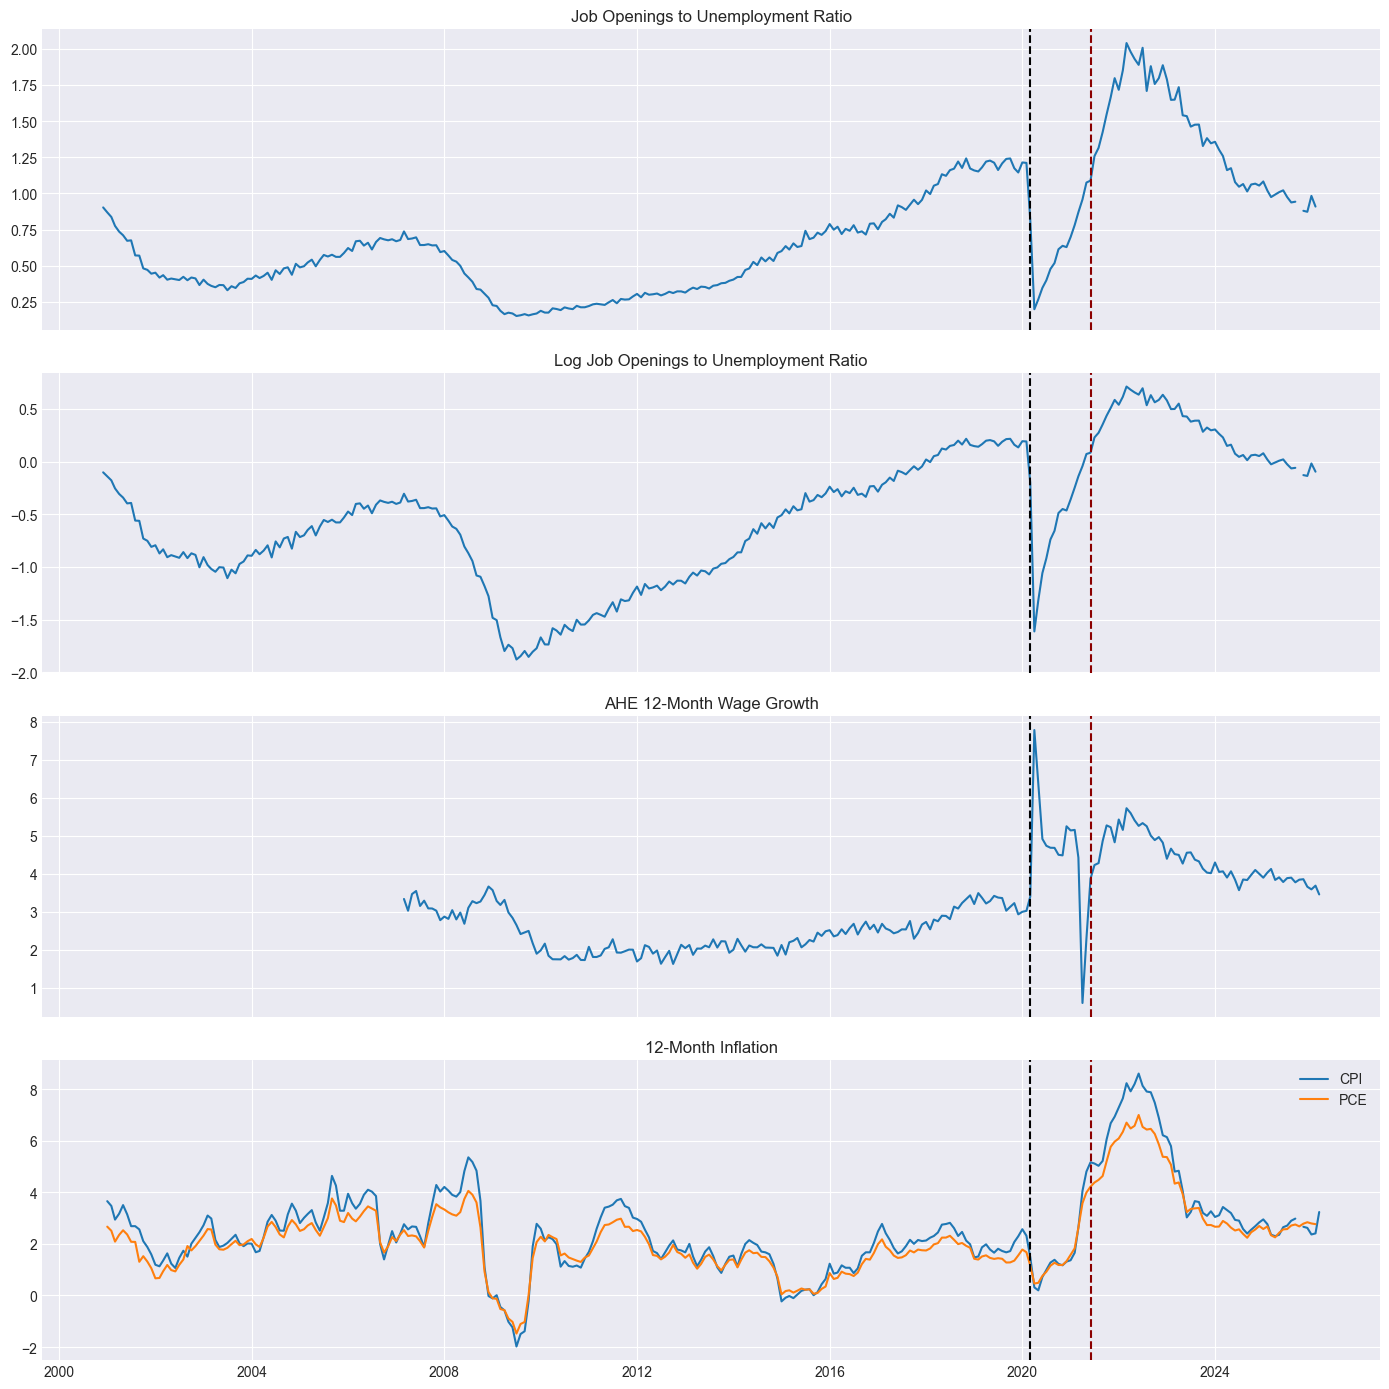

In [33]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(df["date"], df["jolts_ratio"], linewidth=1.5)
axes[0].axvline(candidate_break, color="black", linestyle="--")
axes[0].axvline(post_start, color="darkred", linestyle="--")
axes[0].set_title("Job Openings to Unemployment Ratio")

axes[1].plot(df["date"], df["log_jolts_ratio"], linewidth=1.5)
axes[1].axvline(candidate_break, color="black", linestyle="--")
axes[1].axvline(post_start, color="darkred", linestyle="--")
axes[1].set_title("Log Job Openings to Unemployment Ratio")

axes[2].plot(df["date"], df["ahe_12m_pct"], linewidth=1.5)
axes[2].axvline(candidate_break, color="black", linestyle="--")
axes[2].axvline(post_start, color="darkred", linestyle="--")
axes[2].set_title("AHE 12-Month Wage Growth")

axes[3].plot(df["date"], df["cpi_12m_pct"], linewidth=1.5, label="CPI")
axes[3].plot(df["date"], df["pce_12m_pct"], linewidth=1.5, label="PCE")
axes[3].axvline(candidate_break, color="black", linestyle="--")
axes[3].axvline(post_start, color="darkred", linestyle="--")
axes[3].set_title("12-Month Inflation")
axes[3].legend()

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_core_series.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

## Regime-Level Summary 

In [34]:
regime_summary = (
    df.groupby("regime")[["jolts_ratio", "log_jolts_ratio", "quits_rate", "unemployment_rate", "ahe_12m_pct", "cpi_12m_pct", "pce_12m_pct"]]
    .agg(["count", "mean", "std", "min", "max"])
    .round(4)
)

regime_summary.to_csv(REPORT_ROOT / "03_regime_summary.csv")
regime_summary

jolts_ratio                             log_jolts_ratio                               quits_rate                             unemployment_rate                       \
                                   count   mean    std    min    max           count    mean    std     min    max      count   mean    std    min    max             count   mean    std    min   
regime                                                                                                                                                                                             
Pandemic Shock (2020-2021H1)          17 0.6892 0.3092 0.1995 1.2138              17 -0.4843 0.5165 -1.6118 0.1938         17 2.2059 0.3112 1.5000 2.7000                17 7.5176 3.1463 3.5000   
Post-Pandemic (2021-06+)              56 1.3771 0.3567 0.8730 2.0390              56  0.2868 0.2604 -0.1358 0.7124         57 2.3579 0.3530 1.9000 3.0000                57 4.0193 0.4775 3.4000   
Pre-2020                             229 0.5594 0.2841 0.1529 1.2419             229 -0.7140 0.5312 -1.8782 0.2166        229 1.9074 0.3000 1.2000 2.4000               240 5.8812 1.8095 3.5000   

                                     ahe_12m_pct                             cpi_12m_pct                              pce_12m_pct                               
                                 max       count   mean    std    min    max       count   mean    std     min    max       count   mean    std     min    max  
regime                                                                                                                                                          
Pandemic Shock (2020-2021H1) 14.8000          17 4.3808 1.6120 0.5974 7.7854          17 1.7319 1.2217  0.1980 4.8011          17 1.5849 0.9817  0.4614 3.9917  
Post-Pandemic (2021-06+)      5.9000          58 4.3543 0.5928 3.4566 5.7269          57 4.4440 2.0558  2.2988 8.5988          57 3.9168 1.5644  2.2356 6.9932  
Pre-2020                     10.0000         154 2.4821 0.5418 1.6261 3.6655         228 2.0802 1.2151 -1.9782 5.3517         228 1.7790 0.9713 -1.4769 4.0524

### Unit Root and Stationarity Checks

In [35]:
unit_rows = []

for col in ["jolts_ratio", "log_jolts_ratio", "ahe_12m_pct", "cpi_12m_pct", "pce_12m_pct"]:
    for label in [PRE_LABEL, SHOCK_LABEL, POST_LABEL]:
        use = df.loc[df["regime"] == label, col].dropna()

        if len(use) < 24:
            continue

        out = adfuller(use, autolag="AIC")
        unit_rows.append(
            {
                "col": col,
                "regime": label,
                "adf_stat": out[0],
                "p_value": out[1],
                "lags": out[2],
                "obs": out[3],
            }
        )

unit_data = pd.DataFrame(unit_rows)

unit_data.to_csv(REPORT_ROOT / "03_unit_root_tests.csv", index=False)
unit_data

,col,regime,adf_stat,p_value,lags,obs
0,jolts_ratio,Pre-2020,-1.2358,0.6580,11,217
1,jolts_ratio,Post-Pandemic (2021-06+),-0.4089,0.9086,2,53
2,log_jolts_ratio,Pre-2020,-1.4679,0.5493,11,217
3,log_jolts_ratio,Post-Pandemic (2021-06+),-0.2184,0.9363,2,53
4,ahe_12m_pct,Pre-2020,-1.0738,0.7254,13,140
5,ahe_12m_pct,Post-Pandemic (2021-06+),-0.7264,0.8398,2,55
6,cpi_12m_pct,Pre-2020,-2.5658,0.1003,15,212
7,cpi_12m_pct,Post-Pandemic (2021-06+),-2.7363,0.0680,7,49
8,pce_12m_pct,Pre-2020,-2.3672,0.1512,15,212
9,pce_12m_pct,Post-Pandemic (2021-06+),-3.0356,0.0317,9,47


### Level Shift Diagnostics

In [36]:
def mean_test(data, col, left_date, right_date):
    left = data.loc[data["date"] < left_date, col].dropna()
    right = data.loc[data["date"] >= right_date, col].dropna()

    test = stats.ttest_ind(left, right, equal_var=False, nan_policy="omit")

    return {
        "col": col,
        "left_date": left_date,
        "right_date": right_date,
        "mean_left": left.mean(),
        "mean_right": right.mean(),
        "diff": right.mean() - left.mean(),
        "t_stat": test.statistic,
        "p_value": test.pvalue,
        "n_left": len(left),
        "n_right": len(right),
    }

In [37]:
level_rows = []

for col in ["jolts_ratio", "log_jolts_ratio", "ahe_12m_pct", "cpi_12m_pct", "pce_12m_pct"]:
    level_rows.append(mean_test(df, col, candidate_break, post_start))

level_data = pd.DataFrame(level_rows)
level_data.to_csv(REPORT_ROOT / "03_level_shift_tests.csv", index=False)
level_data

,col,left_date,right_date,mean_left,mean_right,diff,t_stat,p_value,n_left,n_right
0,jolts_ratio,2020-03-01,2021-06-01,0.5651,1.3771,0.8120,-15.8213,0.0000,231,56
1,log_jolts_ratio,2020-03-01,2021-06-01,-0.7061,0.2868,0.9930,-20.0502,0.0000,231,56
2,ahe_12m_pct,2020-03-01,2021-06-01,2.4889,4.3543,1.8654,-20.9361,0.0000,156,58
3,cpi_12m_pct,2020-03-01,2021-06-01,2.0833,4.4440,2.3607,-8.3193,0.0000,230,57
4,pce_12m_pct,2020-03-01,2021-06-01,1.7785,3.9168,2.1383,-9.8632,0.0000,230,57


In [38]:
bench_rows = []

for label, part in [
    (PRE_LABEL, df[df["date"] < shock_start].copy()),
    (POST_LABEL, df[df["date"] >= post_start].copy()),
]:
    use, model = fit_model(part, "cpi_forward_12", ["unemployment_rate"], cov_lag=12)
    if model is not None:
        out = coef_table(model, "cpi_forward_12", label)
        out["model_name"] = "baseline_phillips"
        bench_rows.append(out)

phillips_data = pd.concat(bench_rows, axis=0).reset_index(drop=True)
phillips_data.to_csv(REPORT_ROOT / "03_phillips_benchmark.csv", index=False)

phillips_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name
0,Pre-2020,cpi_forward_12,const,2.2862,0.5806,3.9376,0.0001,0.0040,-0.0002,240,baseline_phillips
1,Pre-2020,cpi_forward_12,unemployment_rate,-0.0421,0.0866,-0.4863,0.6267,0.0040,-0.0002,240,baseline_phillips
2,Post-Pandemic (2021-06+),cpi_forward_12,const,-5.9231,1.6367,-3.6189,0.0003,0.4769,0.4648,45,baseline_phillips
3,Post-Pandemic (2021-06+),cpi_forward_12,unemployment_rate,2.4813,0.4816,5.1523,0.0000,0.4769,0.4648,45,baseline_phillips


### Tightness Benchmark Regressions

In [39]:
base_rows = []

for y_col in ["wage_forward_3", "wage_forward_6", "wage_forward_12", "cpi_forward_3", "cpi_forward_6", "cpi_forward_12", "pce_forward_3", "pce_forward_6", "pce_forward_12"]:
    for label, part in [
        (PRE_LABEL, df[df["date"] < shock_start].copy()),
        (POST_LABEL, df[df["date"] >= post_start].copy()),
    ]:
        use, model = fit_model(part, y_col, ["log_jolts_ratio"], cov_lag=12)
        if model is not None:
            out = coef_table(model, y_col, label)
            out["model_name"] = "tightness_only"
            base_rows.append(out)

base_data = pd.concat(base_rows, axis=0).reset_index(drop=True)
base_data.to_csv(REPORT_ROOT / "03_tightness_only_results.csv", index=False)

base_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name
0,Pre-2020,wage_forward_3,const,3.0473,0.1146,26.5867,0.0000,0.3221,0.3180,166,tightness_only
1,Pre-2020,wage_forward_3,log_jolts_ratio,0.7227,0.0830,8.7077,0.0000,0.3221,0.3180,166,tightness_only
2,Post-Pandemic (2021-06+),wage_forward_3,const,3.9181,0.1916,20.4540,0.0000,0.1565,0.1403,54,tightness_only
3,Post-Pandemic (2021-06+),wage_forward_3,log_jolts_ratio,1.2095,0.2950,4.0997,0.0000,0.1565,0.1403,54,tightness_only
4,Pre-2020,wage_forward_6,const,3.3696,0.2951,11.4183,0.0000,0.2788,0.2744,166,tightness_only
5,Pre-2020,wage_forward_6,log_jolts_ratio,1.0189,0.2569,3.9669,0.0001,0.2788,0.2744,166,tightness_only
6,Post-Pandemic (2021-06+),wage_forward_6,const,3.9058,0.1941,20.1211,0.0000,0.1764,0.1599,52,tightness_only
7,Post-Pandemic (2021-06+),wage_forward_6,log_jolts_ratio,1.0521,0.2852,3.6895,0.0002,0.1764,0.1599,52,tightness_only
8,Pre-2020,wage_forward_12,const,3.3846,0.2292,14.7686,0.0000,0.5454,0.5426,166,tightness_only
9,Pre-2020,wage_forward_12,log_jolts_ratio,1.0458,0.2025,5.1639,0.0000,0.5454,0.5426,166,tightness_only


## Persistence-Controlled Regressions

In [40]:
wage_rows = []

for horizon in [3, 6, 12]:
    y_col = f"wage_forward_{horizon}"
    x_cols = ["log_jolts_ratio", "ahe_12m_pct_lag_1"]

    for label, part in [
        (PRE_LABEL, df[df["date"] < shock_start].copy()),
        (POST_LABEL, df[df["date"] >= post_start].copy()),
    ]:
        use, model = fit_model(part, y_col, x_cols, cov_lag=12)
        if model is not None:
            out = coef_table(model, y_col, label)
            out["model_name"] = "wage_persist"
            out["horizon"] = horizon
            wage_rows.append(out)

wage_data = pd.concat(wage_rows, axis=0).reset_index(drop=True)
wage_data.to_csv(REPORT_ROOT / "03_wage_predictive_results.csv", index=False)

wage_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name,horizon
0,Pre-2020,wage_forward_3,const,1.8803,0.3344,5.6222,0.0000,0.3822,0.3740,153,wage_persist,3
1,Pre-2020,wage_forward_3,log_jolts_ratio,0.5187,0.0835,6.2089,0.0000,0.3822,0.3740,153,wage_persist,3
2,Pre-2020,wage_forward_3,ahe_12m_pct_lag_1,0.3896,0.1303,2.9909,0.0028,0.3822,0.3740,153,wage_persist,3
3,Post-Pandemic (2021-06+),wage_forward_3,const,5.6091,1.5097,3.7153,0.0002,0.1947,0.1631,54,wage_persist,3
4,Post-Pandemic (2021-06+),wage_forward_3,log_jolts_ratio,2.1588,0.8909,2.4231,0.0154,0.1947,0.1631,54,wage_persist,3
5,Post-Pandemic (2021-06+),wage_forward_3,ahe_12m_pct_lag_1,-0.4507,0.3717,-1.2125,0.2253,0.1947,0.1631,54,wage_persist,3
6,Pre-2020,wage_forward_6,const,2.1085,0.3958,5.3274,0.0000,0.2994,0.2900,153,wage_persist,6
7,Pre-2020,wage_forward_6,log_jolts_ratio,0.8185,0.2188,3.7404,0.0002,0.2994,0.2900,153,wage_persist,6
8,Pre-2020,wage_forward_6,ahe_12m_pct_lag_1,0.4384,0.1657,2.6462,0.0081,0.2994,0.2900,153,wage_persist,6
9,Post-Pandemic (2021-06+),wage_forward_6,const,5.2826,1.4649,3.6061,0.0003,0.2175,0.1856,52,wage_persist,6


In [41]:
inflation_rows = []

for prefix in ["cpi", "pce"]:
    for horizon in [3, 6, 12]:
        y_col = f"{prefix}_forward_{horizon}"
        x_cols = ["log_jolts_ratio", f"{prefix}_12m_pct_lag_1"]

        for label, part in [
            (PRE_LABEL, df[df["date"] < shock_start].copy()),
            (POST_LABEL, df[df["date"] >= post_start].copy()),
        ]:
            use, model = fit_model(part, y_col, x_cols, cov_lag=12)
            if model is not None:
                out = coef_table(model, y_col, label)
                out["model_name"] = f"{prefix}_persist"
                out["horizon"] = horizon
                inflation_rows.append(out)

inflation_data = pd.concat(inflation_rows, axis=0).reset_index(drop=True)
inflation_data.to_csv(REPORT_ROOT / "03_inflation_predictive_results.csv", index=False)
inflation_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name,horizon
0,Pre-2020,cpi_forward_3,const,3.0732,0.9949,3.0891,0.0020,0.0327,0.0240,227,cpi_persist,3
1,Pre-2020,cpi_forward_3,log_jolts_ratio,0.3574,0.5047,0.7083,0.4788,0.0327,0.0240,227,cpi_persist,3
2,Pre-2020,cpi_forward_3,cpi_12m_pct_lag_1,-0.3763,0.3612,-1.0418,0.2975,0.0327,0.0240,227,cpi_persist,3
3,Post-Pandemic (2021-06+),cpi_forward_3,const,1.5522,0.8650,1.7945,0.0727,0.2211,0.1893,52,cpi_persist,3
4,Post-Pandemic (2021-06+),cpi_forward_3,log_jolts_ratio,0.4362,2.0982,0.2079,0.8353,0.2211,0.1893,52,cpi_persist,3
5,Post-Pandemic (2021-06+),cpi_forward_3,cpi_12m_pct_lag_1,0.5373,0.3323,1.6172,0.1058,0.2211,0.1893,52,cpi_persist,3
6,Pre-2020,cpi_forward_6,const,2.4841,0.7969,3.1173,0.0018,0.0191,0.0103,227,cpi_persist,6
7,Pre-2020,cpi_forward_6,log_jolts_ratio,0.0737,0.4133,0.1782,0.8585,0.0191,0.0103,227,cpi_persist,6
8,Pre-2020,cpi_forward_6,cpi_12m_pct_lag_1,-0.2130,0.3106,-0.6857,0.4929,0.0191,0.0103,227,cpi_persist,6
9,Post-Pandemic (2021-06+),cpi_forward_6,const,1.4409,1.0049,1.4339,0.1516,0.2079,0.1749,51,cpi_persist,6


## Interaction Models for Post-Break Slope Change

In [42]:
interaction_rows = []

for y_col, lag_col in [
    ("wage_forward_3", "ahe_12m_pct_lag_1"),
    ("wage_forward_6", "ahe_12m_pct_lag_1"),
    ("wage_forward_12", "ahe_12m_pct_lag_1"),
    ("cpi_forward_3", "cpi_12m_pct_lag_1"),
    ("cpi_forward_6", "cpi_12m_pct_lag_1"),
    ("cpi_forward_12", "cpi_12m_pct_lag_1"),
    ("pce_forward_3", "pce_12m_pct_lag_1"),
    ("pce_forward_6", "pce_12m_pct_lag_1"),
    ("pce_forward_12", "pce_12m_pct_lag_1"),
]:
    use = df[["date", y_col, "log_jolts_ratio", "post_regime", lag_col]].dropna().copy()
    use["jolts_x_post"] = use["log_jolts_ratio"] * use["post_regime"]

    x = sm.add_constant(use[["log_jolts_ratio", "post_regime", "jolts_x_post", lag_col]])
    y = use[y_col]
    model = sm.OLS(y, x).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

    out = coef_table(model, y_col, "full_sample")
    out["model_name"] = "interaction_post"
    interaction_rows.append(out)

interaction_data = pd.concat(interaction_rows, axis=0).reset_index(drop=True)
interaction_data.to_csv(REPORT_ROOT / "03_interaction_results.csv", index=False)
interaction_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name
0,full_sample,wage_forward_3,const,3.8301,1.2533,3.0560,0.0022,0.2388,0.2249,224,interaction_post
1,full_sample,wage_forward_3,log_jolts_ratio,1.5037,0.7139,2.1062,0.0352,0.2388,0.2249,224,interaction_post
2,full_sample,wage_forward_3,post_regime,0.1531,0.4697,0.3260,0.7444,0.2388,0.2249,224,interaction_post
3,full_sample,wage_forward_3,jolts_x_post,-0.2577,0.5415,-0.4759,0.6341,0.2388,0.2249,224,interaction_post
4,full_sample,wage_forward_3,ahe_12m_pct_lag_1,-0.0173,0.2590,-0.0670,0.9466,0.2388,0.2249,224,interaction_post
5,full_sample,wage_forward_6,const,3.0228,0.7283,4.1505,0.0000,0.4462,0.4360,222,interaction_post
6,full_sample,wage_forward_6,log_jolts_ratio,1.2204,0.4318,2.8266,0.0047,0.4462,0.4360,222,interaction_post
7,full_sample,wage_forward_6,post_regime,0.0658,0.3639,0.1807,0.8566,0.4462,0.4360,222,interaction_post
8,full_sample,wage_forward_6,jolts_x_post,-0.6572,0.5088,-1.2916,0.1965,0.4462,0.4360,222,interaction_post
9,full_sample,wage_forward_6,ahe_12m_pct_lag_1,0.2207,0.1458,1.5138,0.1301,0.4462,0.4360,222,interaction_post


## Equations for Forecasting

### Chow Tests on Forecasting Equations

In [43]:
break_rows = []

for y_col, x_cols in [
    ("wage_forward_3", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("wage_forward_6", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("wage_forward_12", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("cpi_forward_3", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("cpi_forward_6", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("cpi_forward_12", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("pce_forward_3", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
    ("pce_forward_6", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
    ("pce_forward_12", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
]:
    out_one = chow_test(df, y_col, x_cols, candidate_break)
    out_two = chow_test(df, y_col, x_cols, post_start)

    if out_one is not None:
        out_one["test_name"] = "chow_2020_03"
        break_rows.append(out_one)

    if out_two is not None:
        out_two["test_name"] = "chow_2021_06"
        break_rows.append(out_two)

break_data = pd.DataFrame(break_rows)
break_data

,y_col,break_date,f_stat,p_value,n_left,n_right,k,test_name
0,wage_forward_3,2020-03-01,4.0967,0.0074,155,69,3,chow_2020_03
1,wage_forward_3,2021-06-01,0.1475,0.9312,170,54,3,chow_2021_06
2,wage_forward_6,2020-03-01,3.7289,0.0121,155,67,3,chow_2020_03
3,wage_forward_6,2021-06-01,0.9653,0.4100,170,52,3,chow_2021_06
4,wage_forward_12,2020-03-01,10.0999,0.0000,155,61,3,chow_2020_03
5,wage_forward_12,2021-06-01,7.8320,0.0001,170,46,3,chow_2021_06
6,cpi_forward_3,2020-03-01,12.8188,0.0000,229,67,3,chow_2020_03
7,cpi_forward_3,2021-06-01,10.0030,0.0000,244,52,3,chow_2021_06
8,cpi_forward_6,2020-03-01,19.8498,0.0000,229,66,3,chow_2020_03
9,cpi_forward_6,2021-06-01,11.3161,0.0000,244,51,3,chow_2021_06


### Sup-F Style Break Search

In [44]:
sup_rows = []

for y_col, x_cols in [
    ("wage_forward_3", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("wage_forward_6", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("wage_forward_12", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("cpi_forward_3", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("cpi_forward_6", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("cpi_forward_12", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("pce_forward_3", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
    ("pce_forward_6", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
    ("pce_forward_12", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
]:
    best, path = sup_f_test(df, y_col, x_cols, trim_pct=0.15)
    if best is not None:
        best["test_name"] = "sup_f"
        sup_rows.append(best)

sup_data = pd.DataFrame(sup_rows)
sup_data.to_csv(REPORT_ROOT / "03_sup_f_results.csv", index=False)

sup_data

,y_col,break_date,f_stat,p_value,n_left,n_right,k,test_name
0,wage_forward_3,2019-12-01,18.4112,0.0000,152,72,3,sup_f
1,wage_forward_6,2019-10-01,27.5730,0.0000,150,72,3,sup_f
2,wage_forward_12,2019-04-01,43.4986,0.0000,144,72,3,sup_f
3,cpi_forward_3,2010-05-01,24.0818,0.0000,111,185,3,sup_f
4,cpi_forward_6,2009-08-01,24.9494,0.0000,102,193,3,sup_f
5,cpi_forward_12,2020-06-01,43.2772,0.0000,232,57,3,sup_f
6,pce_forward_3,2009-12-01,23.1202,0.0000,106,191,3,sup_f
7,pce_forward_6,2020-10-01,31.6475,0.0000,236,59,3,sup_f
8,pce_forward_12,2020-08-01,54.0817,0.0000,234,55,3,sup_f


## Forward Correlation Across Horizons

In [45]:
wage_corr = forward_corr(df, "log_jolts_ratio", "wage", [3, 6, 12])
cpi_corr = forward_corr(df, "log_jolts_ratio", "cpi", [3, 6, 12])
pce_corr = forward_corr(df, "log_jolts_ratio", "pce", [3, 6, 12])

lead_data = pd.concat([wage_corr, cpi_corr, pce_corr], axis=0).reset_index(drop=True)
lead_data.to_csv(REPORT_ROOT / "03_forward_correlation.csv", index=False)

lead_data

,y_col,horizon,corr_all,corr_pre,corr_shock,corr_post
0,wage,3,0.4880,0.5675,0.8398,0.3956
1,wage,6,0.6549,0.5280,0.9128,0.4199
2,wage,12,0.7619,0.7385,0.8548,0.3857
3,cpi,3,0.2192,0.0424,-0.2566,0.4283
4,cpi,6,0.2533,-0.0010,0.0228,0.3517
5,cpi,12,0.2486,-0.0325,0.0468,0.1839
6,pce,3,0.2456,-0.0029,-0.1146,0.4507
7,pce,6,0.2666,-0.0576,0.1183,0.3561
8,pce,12,0.2486,-0.1068,0.0618,0.1823


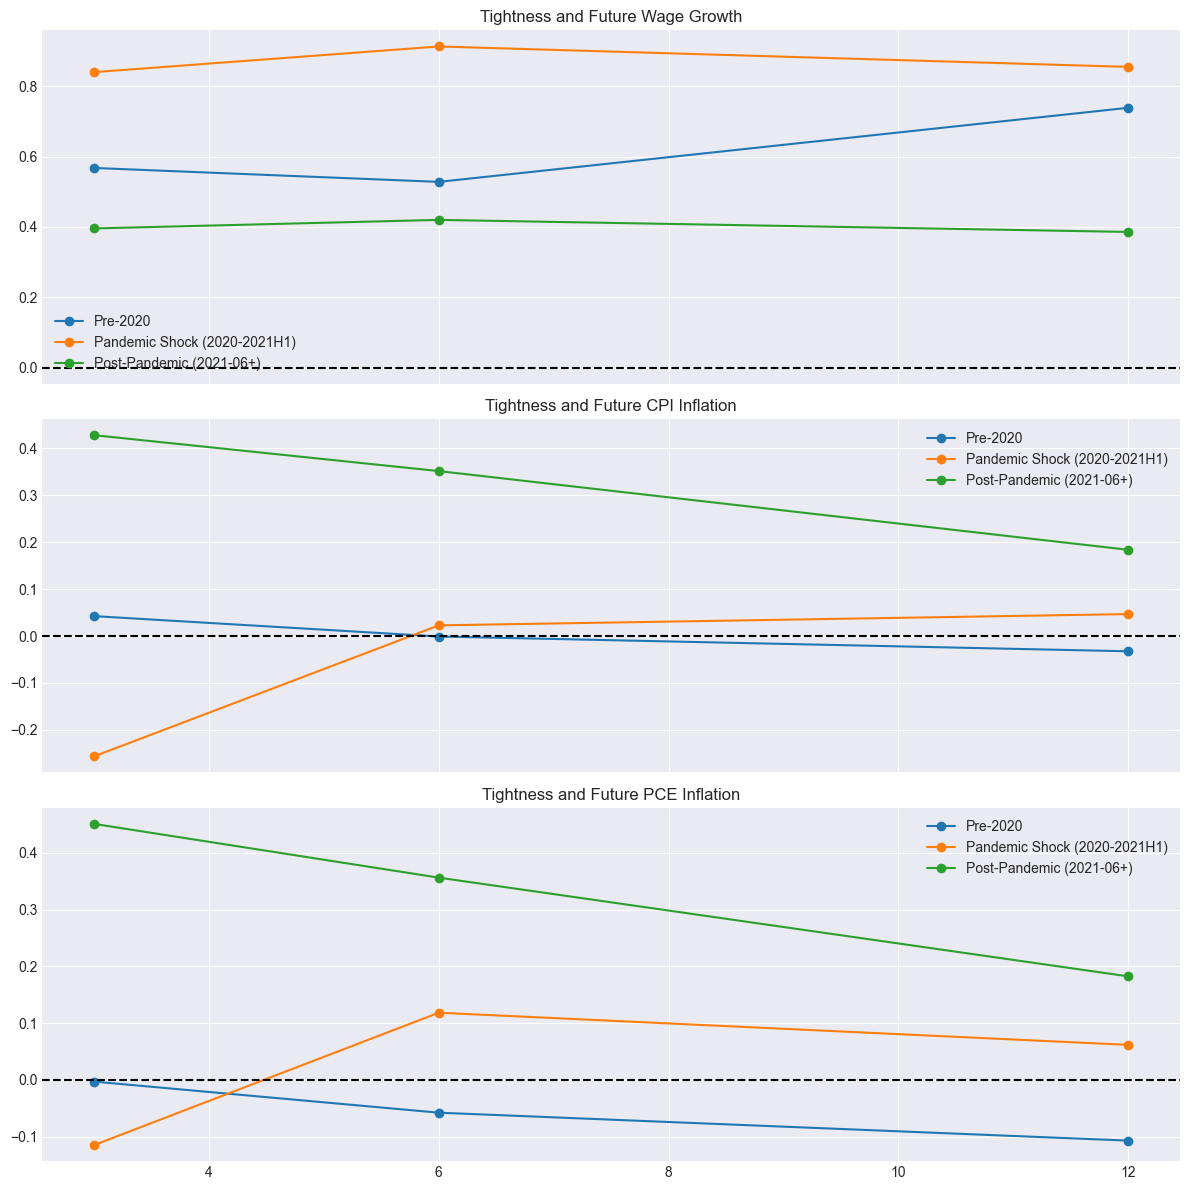

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for label, col in [("corr_pre", PRE_LABEL), ("corr_shock", SHOCK_LABEL), ("corr_post", POST_LABEL)]:
    axes[0].plot(wage_corr["horizon"], wage_corr[label], marker="o", linewidth=1.5, label=col)
    axes[1].plot(cpi_corr["horizon"], cpi_corr[label], marker="o", linewidth=1.5, label=col)
    axes[2].plot(pce_corr["horizon"], pce_corr[label], marker="o", linewidth=1.5, label=col)

axes[0].set_title("Tightness and Future Wage Growth")
axes[1].set_title("Tightness and Future CPI Inflation")
axes[2].set_title("Tightness and Future PCE Inflation")

for ax in axes:
    ax.axhline(0, color="black", linestyle="--")
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_forward_correlation.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

## Rolling Regressions 

### Wage Prediction

In [47]:
roll_wage_3 = rolling_model(df, "wage_forward_3", ["log_jolts_ratio", "ahe_12m_pct_lag_1"], window=60, cov_lag=12)
roll_wage_6 = rolling_model(df, "wage_forward_6", ["log_jolts_ratio", "ahe_12m_pct_lag_1"], window=60, cov_lag=12)
roll_wage_12 = rolling_model(df, "wage_forward_12", ["log_jolts_ratio", "ahe_12m_pct_lag_1"], window=60, cov_lag=12)

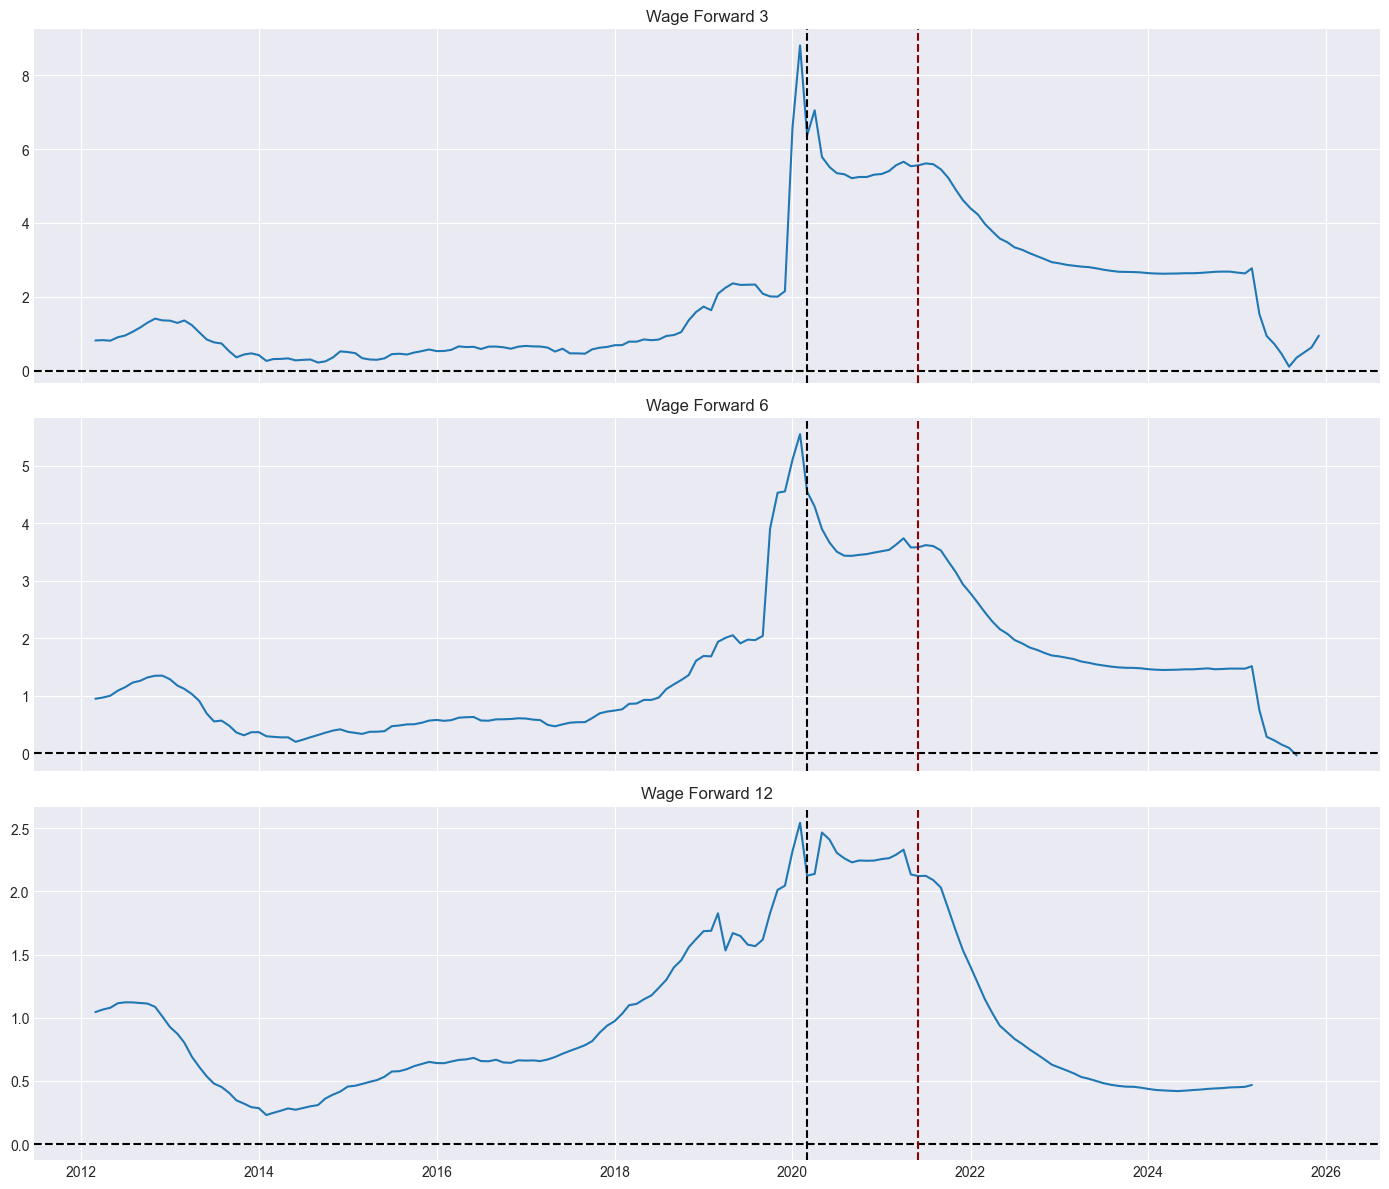

In [48]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for roll, title, ax in [
    (roll_wage_3, "Wage Forward 3", axes[0]),
    (roll_wage_6, "Wage Forward 6", axes[1]),
    (roll_wage_12, "Wage Forward 12", axes[2]),
]:
    ax.plot(roll["date"], roll["coef_log_jolts_ratio"], linewidth=1.5)
    ax.axhline(0, color="black", linestyle="--")
    ax.axvline(candidate_break, color="black", linestyle="--")
    ax.axvline(post_start, color="darkred", linestyle="--")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_rolling_wage_coef.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Inflation Prediction

In [49]:
roll_cpi_3 = rolling_model(df, "cpi_forward_3", ["log_jolts_ratio", "cpi_12m_pct_lag_1"], window=60, cov_lag=12)
roll_cpi_6 = rolling_model(df, "cpi_forward_6", ["log_jolts_ratio", "cpi_12m_pct_lag_1"], window=60, cov_lag=12)
roll_cpi_12 = rolling_model(df, "cpi_forward_12", ["log_jolts_ratio", "cpi_12m_pct_lag_1"], window=60, cov_lag=12)

roll_pce_3 = rolling_model(df, "pce_forward_3", ["log_jolts_ratio", "pce_12m_pct_lag_1"], window=60, cov_lag=12)
roll_pce_6 = rolling_model(df, "pce_forward_6", ["log_jolts_ratio", "pce_12m_pct_lag_1"], window=60, cov_lag=12)
roll_pce_12 = rolling_model(df, "pce_forward_12", ["log_jolts_ratio", "pce_12m_pct_lag_1"], window=60, cov_lag=12)

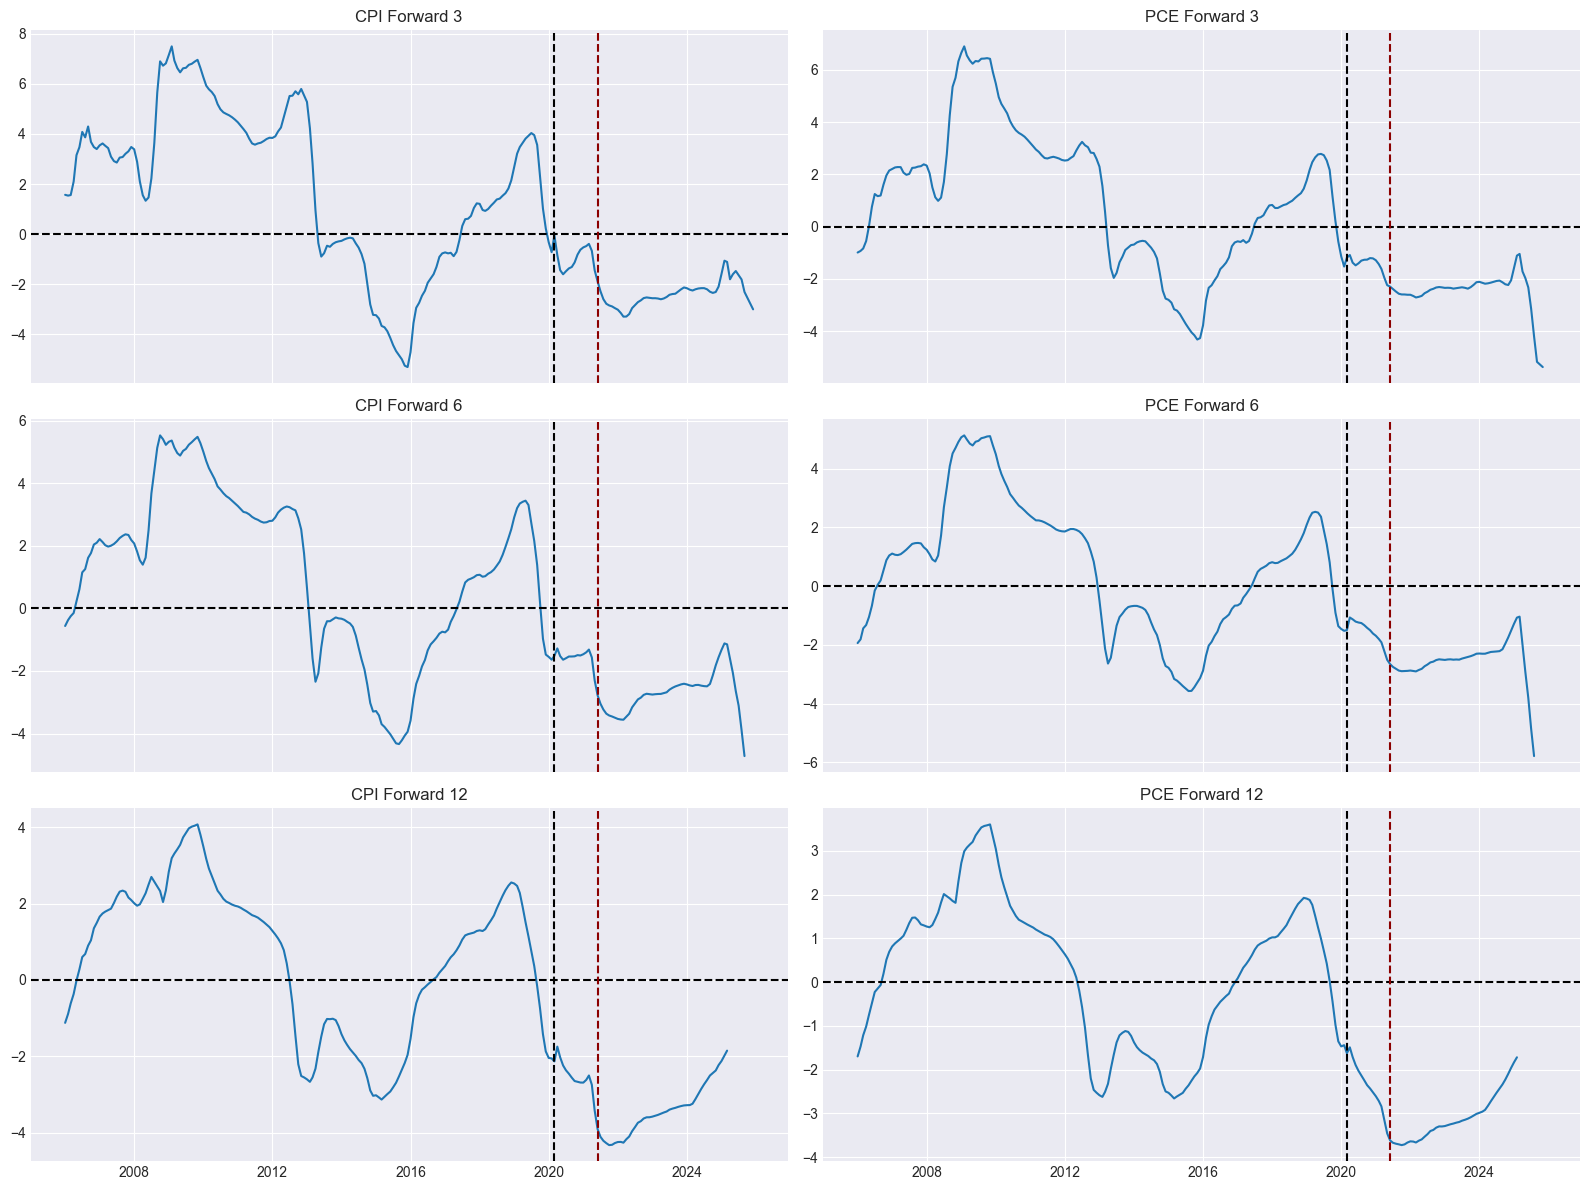

In [50]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

for roll, title, ax in [
    (roll_cpi_3, "CPI Forward 3", axes[0, 0]),
    (roll_cpi_6, "CPI Forward 6", axes[1, 0]),
    (roll_cpi_12, "CPI Forward 12", axes[2, 0]),
    (roll_pce_3, "PCE Forward 3", axes[0, 1]),
    (roll_pce_6, "PCE Forward 6", axes[1, 1]),
    (roll_pce_12, "PCE Forward 12", axes[2, 1]),
]:
    ax.plot(roll["date"], roll["coef_log_jolts_ratio"], linewidth=1.5)
    ax.axhline(0, color="black", linestyle="--")
    ax.axvline(candidate_break, color="black", linestyle="--")
    ax.axvline(post_start, color="darkred", linestyle="--")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_rolling_inflation_coef.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

## CUSUM Stability on the Forecasting Equation

In [51]:
def cusum_model(data, y_col, x_cols):
    use = data[["date", y_col] + x_cols].dropna().copy()
    x = sm.add_constant(use[x_cols])
    y = use[y_col]
    model = sm.OLS(y, x).fit()
    stat, p_value, crit = breaks_cusumolsresid(model.resid, ddof=x.shape[1])
    return use, model, stat, p_value, crit


cusum_rows = []

for y_col, x_cols in [
    ("wage_forward_12", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("cpi_forward_12", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("pce_forward_12", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
]:
    use, model, stat, p_value, crit = cusum_model(df, y_col, x_cols)
    cusum_rows.append(
        {
            "y_col": y_col,
            "stat": stat,
            "p_value": p_value,
            "crit_1": crit[0][1],
            "crit_5": crit[1][1],
            "crit_10": crit[2][1],
            "obs": len(use),
        }
    )

cusum_data = pd.DataFrame(cusum_rows)
cusum_data.to_csv(REPORT_ROOT / "03_cusum_results.csv", index=False)

cusum_data

,y_col,stat,p_value,crit_1,crit_5,crit_10,obs
0,wage_forward_12,2.3357,0.0000,1.6300,1.3600,1.2200,216
1,cpi_forward_12,2.9238,0.0000,1.6300,1.3600,1.2200,289
2,pce_forward_12,3.1032,0.0000,1.6300,1.3600,1.2200,289


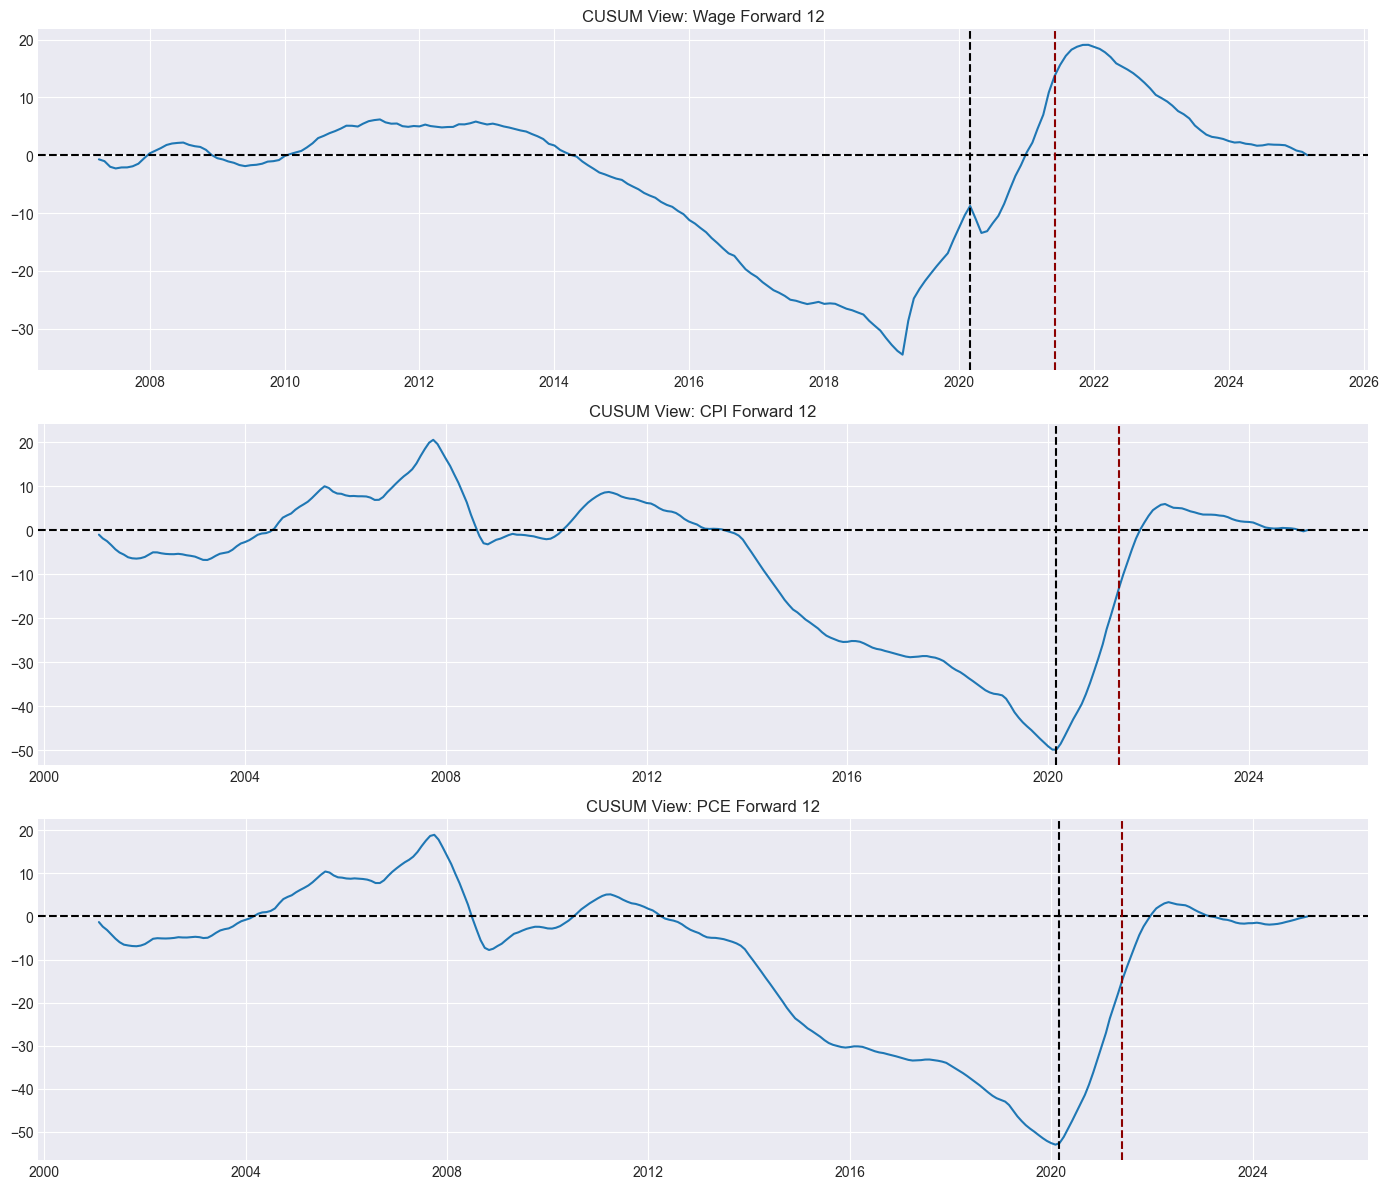

In [52]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, y_col, x_cols, title in [
    (axes[0], "wage_forward_12", ["log_jolts_ratio", "ahe_12m_pct_lag_1"], "CUSUM View: Wage Forward 12"),
    (axes[1], "cpi_forward_12", ["log_jolts_ratio", "cpi_12m_pct_lag_1"], "CUSUM View: CPI Forward 12"),
    (axes[2], "pce_forward_12", ["log_jolts_ratio", "pce_12m_pct_lag_1"], "CUSUM View: PCE Forward 12"),
]:
    use = df[["date", y_col] + x_cols].dropna().copy()
    x = sm.add_constant(use[x_cols])
    y = use[y_col]
    model = sm.OLS(y, x).fit()
    resid = model.resid.values
    path = np.cumsum(resid - resid.mean()) / resid.std(ddof=1)

    ax.plot(use["date"], path, linewidth=1.5)
    ax.axhline(0, color="black", linestyle="--")
    ax.axvline(candidate_break, color="black", linestyle="--")
    ax.axvline(post_start, color="darkred", linestyle="--")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_cusum_paths.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

## Pandemic Shock Versus Post-Pandemic Stabilization

In [53]:
phase_rows = []

for y_col, lag_col in [
    ("wage_forward_3", "ahe_12m_pct_lag_1"),
    ("wage_forward_6", "ahe_12m_pct_lag_1"),
    ("wage_forward_12", "ahe_12m_pct_lag_1"),
    ("cpi_forward_3", "cpi_12m_pct_lag_1"),
    ("cpi_forward_6", "cpi_12m_pct_lag_1"),
    ("cpi_forward_12", "cpi_12m_pct_lag_1"),
    ("pce_forward_3", "pce_12m_pct_lag_1"),
    ("pce_forward_6", "pce_12m_pct_lag_1"),
    ("pce_forward_12", "pce_12m_pct_lag_1"),
]:
    for label, part in [
        (SHOCK_LABEL, df[(df["date"] >= shock_start) & (df["date"] <= shock_end)].copy()),
        (POST_LABEL, df[df["date"] >= post_start].copy()),
    ]:
        use, model = fit_model(part, y_col, ["log_jolts_ratio", lag_col], cov_lag=6)
        if model is not None:
            out = coef_table(model, y_col, label)
            out["model_name"] = "phase_compare"
            phase_rows.append(out)

phase_data = pd.concat(phase_rows, axis=0).reset_index(drop=True)
phase_data.to_csv(REPORT_ROOT / "03_phase_compare_results.csv", index=False)

phase_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name
0,Pandemic Shock (2020-2021H1),wage_forward_3,const,9.0354,3.3983,2.6588,0.0078,0.7100,0.6686,17,phase_compare
1,Pandemic Shock (2020-2021H1),wage_forward_3,log_jolts_ratio,11.5780,2.3378,4.9526,0.0000,0.7100,0.6686,17,phase_compare
2,Pandemic Shock (2020-2021H1),wage_forward_3,ahe_12m_pct_lag_1,0.3539,0.4311,0.8209,0.4117,0.7100,0.6686,17,phase_compare
3,Post-Pandemic (2021-06+),wage_forward_3,const,5.6091,1.6615,3.3760,0.0007,0.1947,0.1631,54,phase_compare
4,Post-Pandemic (2021-06+),wage_forward_3,log_jolts_ratio,2.1588,0.8518,2.5344,0.0113,0.1947,0.1631,54,phase_compare
5,Post-Pandemic (2021-06+),wage_forward_3,ahe_12m_pct_lag_1,-0.4507,0.4131,-1.0910,0.2753,0.1947,0.1631,54,phase_compare
6,Pandemic Shock (2020-2021H1),wage_forward_6,const,4.7905,0.2875,16.6645,0.0000,0.8799,0.8627,17,phase_compare
7,Pandemic Shock (2020-2021H1),wage_forward_6,log_jolts_ratio,5.2021,0.4455,11.6767,0.0000,0.8799,0.8627,17,phase_compare
8,Pandemic Shock (2020-2021H1),wage_forward_6,ahe_12m_pct_lag_1,0.4198,0.0826,5.0802,0.0000,0.8799,0.8627,17,phase_compare
9,Post-Pandemic (2021-06+),wage_forward_6,const,5.2826,1.5642,3.3772,0.0007,0.2175,0.1856,52,phase_compare


## Multicollinearity Behavior

### Heatmaps by Regime

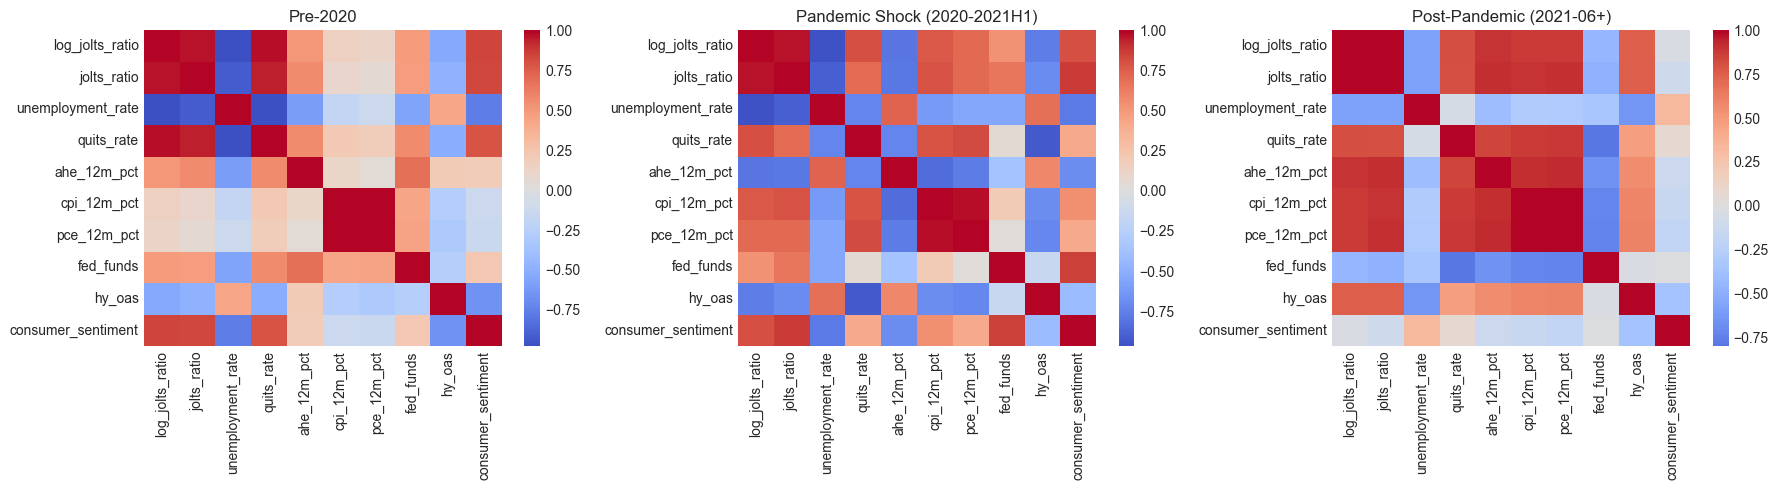

In [54]:
heat_cols = [
    "log_jolts_ratio",
    "jolts_ratio",
    "unemployment_rate",
    "quits_rate",
    "ahe_12m_pct",
    "cpi_12m_pct",
    "pce_12m_pct",
    "fed_funds",
    "hy_oas",
    "consumer_sentiment",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label in zip(axes, [PRE_LABEL, SHOCK_LABEL, POST_LABEL]):
    use = df.loc[df["regime"] == label, heat_cols].dropna().copy()
    sns.heatmap(use.corr(), cmap="coolwarm", center=0, annot=False, ax=ax)
    ax.set_title(label)

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_regime_heatmap.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Variance Inflation Factor

In [55]:
wage_vif = vif_table(df, ["log_jolts_ratio", "ahe_12m_pct_lag_1", "quits_rate", "unemployment_rate", "fed_funds", "hy_oas", "consumer_sentiment"])
wage_vif.to_csv(REPORT_ROOT / "03_wage_vif.csv", index=False)
wage_vif

,col,vif
0,log_jolts_ratio,30.4671
1,unemployment_rate,14.5842
2,quits_rate,10.9222
3,ahe_12m_pct_lag_1,4.1809
4,fed_funds,3.0484
5,hy_oas,2.2060
6,consumer_sentiment,1.7859


In [56]:
inflation_vif = vif_table(df, ["log_jolts_ratio", "cpi_12m_pct_lag_1", "quits_rate", "unemployment_rate", "fed_funds", "hy_oas", "consumer_sentiment"])
inflation_vif.to_csv(REPORT_ROOT / "03_inflation_vif.csv", index=False)
inflation_vif

,col,vif
0,log_jolts_ratio,14.0029
1,unemployment_rate,8.4574
2,quits_rate,7.3864
3,cpi_12m_pct_lag_1,2.5840
4,consumer_sentiment,2.5441
5,fed_funds,1.9018
6,hy_oas,1.7553


## Wage and Inflation Scatter by Regime and Horizon

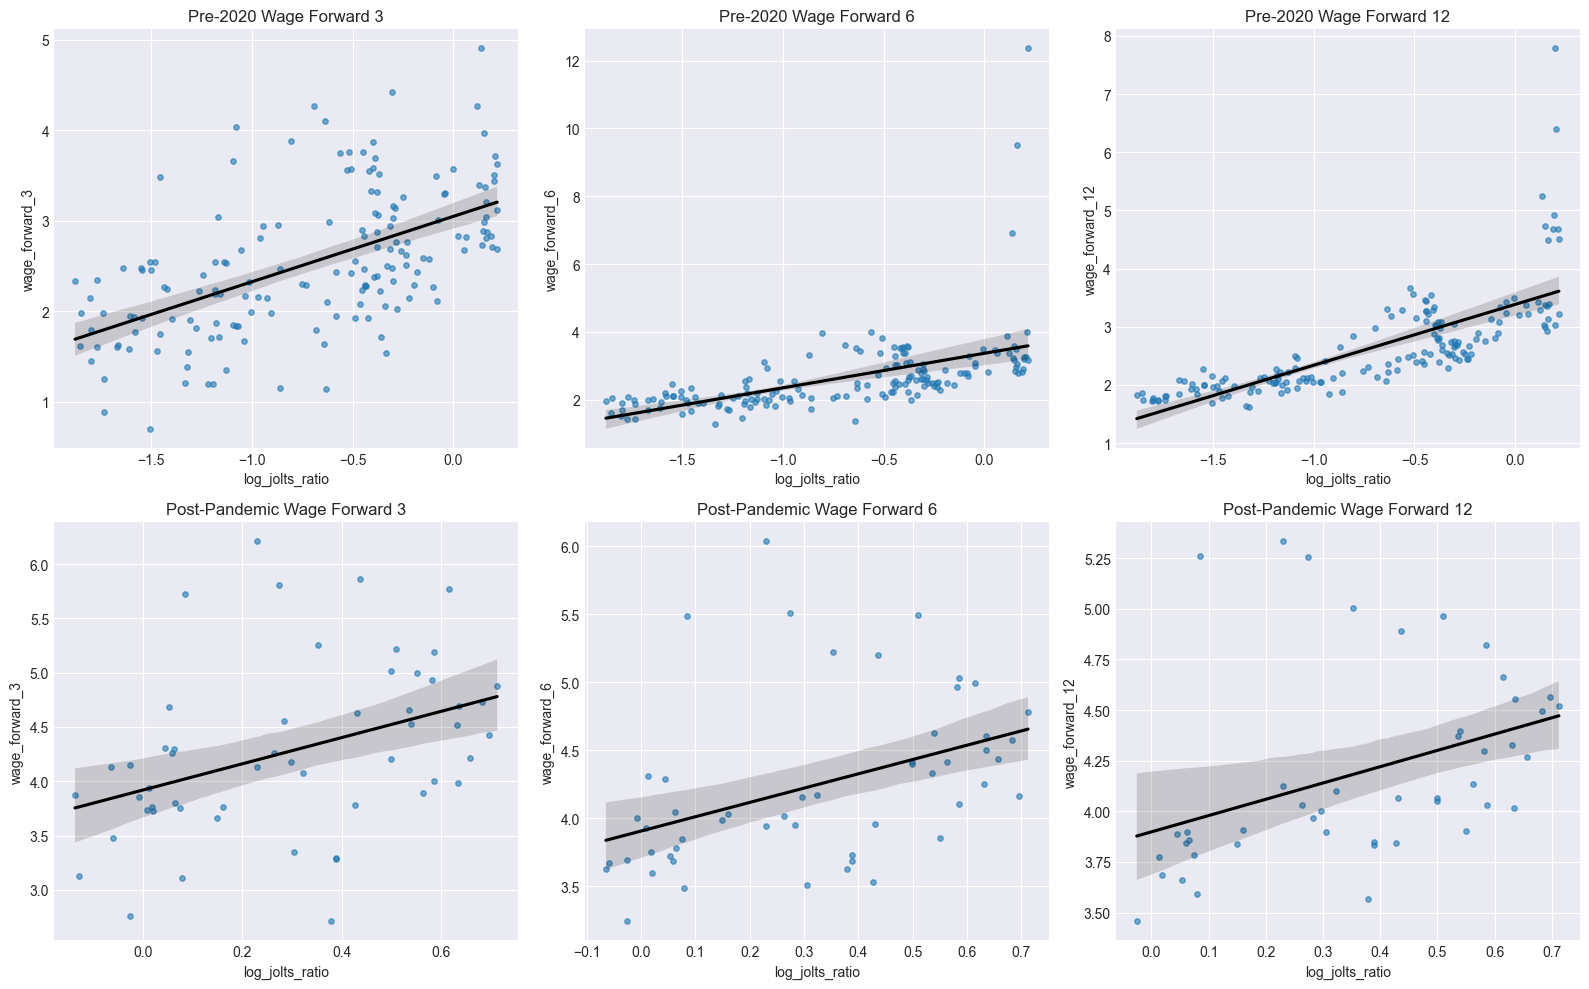

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=False, sharey=False)

for idx, horizon in enumerate([3, 6, 12]):
    sns.regplot(
        data=df[df["regime"] == PRE_LABEL],
        x="log_jolts_ratio",
        y=f"wage_forward_{horizon}",
        scatter_kws={"s": 15, "alpha": 0.6},
        line_kws={"color": "black"},
        ax=axes[0, idx],
    )
    axes[0, idx].set_title(f"Pre-2020 Wage Forward {horizon}")

    sns.regplot(
        data=df[df["regime"] == POST_LABEL],
        x="log_jolts_ratio",
        y=f"wage_forward_{horizon}",
        scatter_kws={"s": 15, "alpha": 0.6},
        line_kws={"color": "black"},
        ax=axes[1, idx],
    )
    axes[1, idx].set_title(f"Post-Pandemic Wage Forward {horizon}")

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_wage_scatter_by_horizon.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

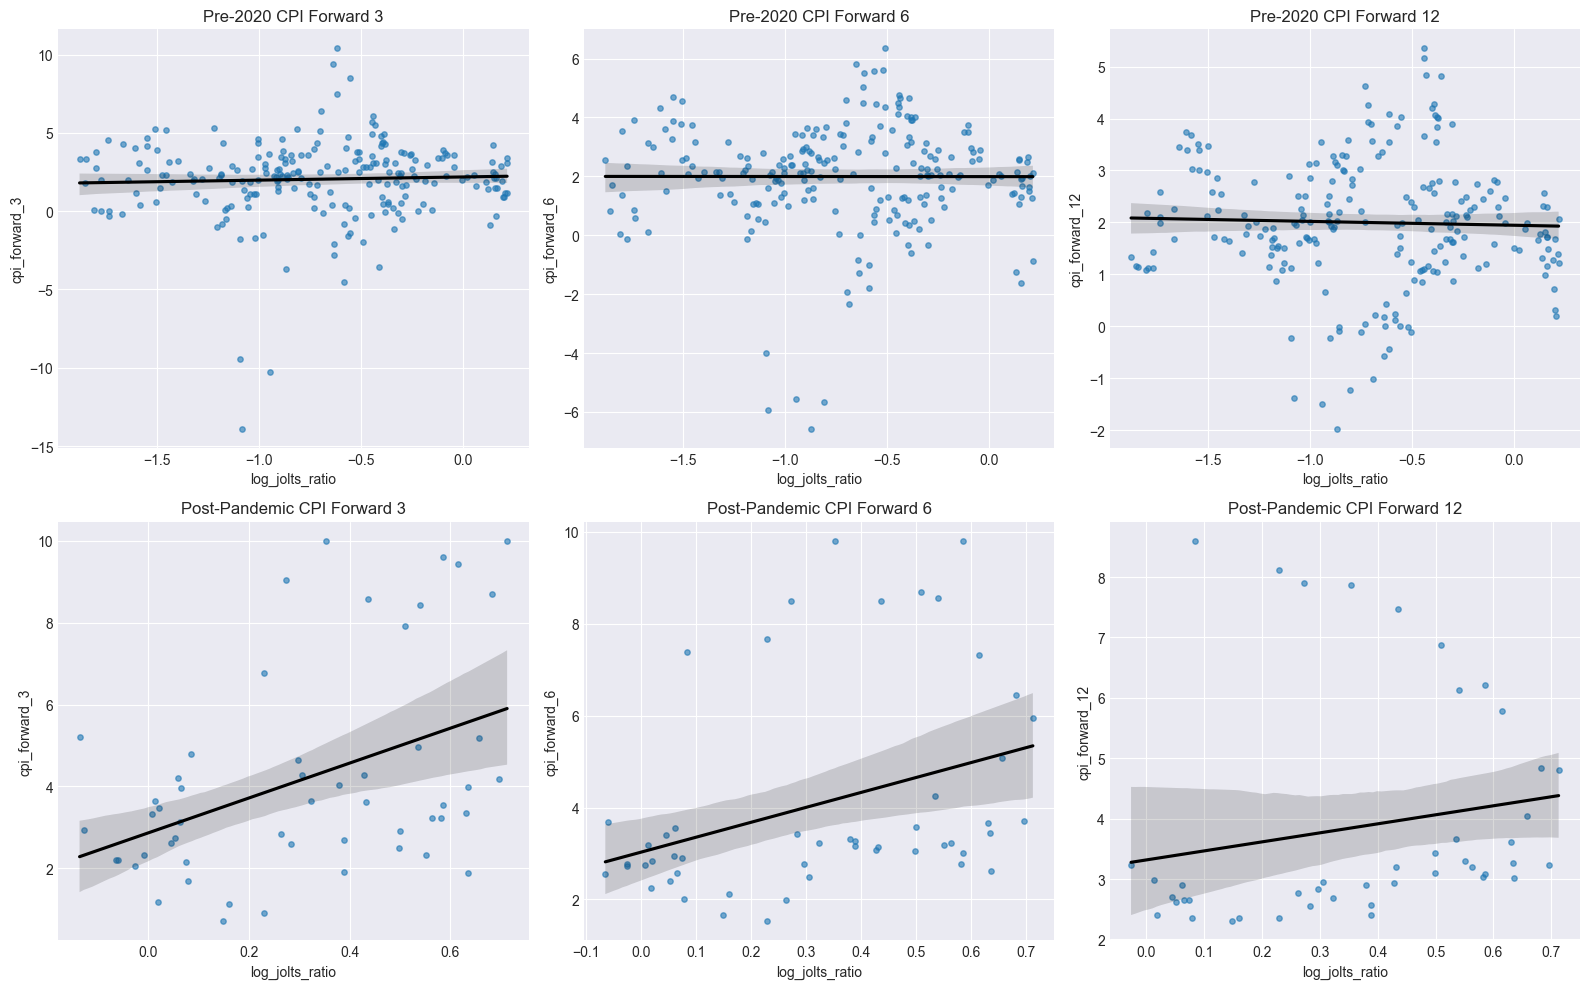

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=False, sharey=False)

for idx, horizon in enumerate([3, 6, 12]):
    sns.regplot(
        data=df[df["regime"] == PRE_LABEL],
        x="log_jolts_ratio",
        y=f"cpi_forward_{horizon}",
        scatter_kws={"s": 15, "alpha": 0.6},
        line_kws={"color": "black"},
        ax=axes[0, idx],
    )
    axes[0, idx].set_title(f"Pre-2020 CPI Forward {horizon}")

    sns.regplot(
        data=df[df["regime"] == POST_LABEL],
        x="log_jolts_ratio",
        y=f"cpi_forward_{horizon}",
        scatter_kws={"s": 15, "alpha": 0.6},
        line_kws={"color": "black"},
        ax=axes[1, idx],
    )
    axes[1, idx].set_title(f"Post-Pandemic CPI Forward {horizon}")

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_cpi_scatter_by_horizon.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

## ECI Frequency Check

In [59]:
eci_audit = df.loc[df["eci_total"].notna(), ["date", "eci_total"]].copy()
eci_audit["month"] = eci_audit["date"].dt.month
eci_months = eci_audit["month"].value_counts().sort_index()

eci_months

month
1     25
2     25
3     25
4     25
5     25
6     25
7     25
8     25
9     25
10    25
11    24
12    24
Name: count, dtype: int64

In [60]:
eci_flag = pd.DataFrame(
    [
        {
            "series": "eci_total",
            "use_in_monthly_forward_analysis": "no",
            "reason": "quarterly release structure",
        }
    ]
)

eci_flag.to_csv(REPORT_ROOT / "03_eci_audit.csv", index=False)
eci_flag

,series,use_in_monthly_forward_analysis,reason
0,eci_total,no,quarterly release structure


In [61]:
summary_audit = pd.DataFrame(
    [
        {"metric": "total_observations", "value": len(df)},
        {"metric": "total_columns", "value": len(df.columns)},
        {"metric": "pre_2020_observations", "value": int((df["regime"] == PRE_LABEL).sum())},
        {"metric": "shock_observations", "value": int((df["regime"] == SHOCK_LABEL).sum())},
        {"metric": "post_observations", "value": int((df["regime"] == POST_LABEL).sum())},
        {"metric": "wage_forward_3_obs", "value": int(df["wage_forward_3"].notna().sum())},
        {"metric": "wage_forward_6_obs", "value": int(df["wage_forward_6"].notna().sum())},
        {"metric": "wage_forward_12_obs", "value": int(df["wage_forward_12"].notna().sum())},
        {"metric": "cpi_forward_3_obs", "value": int(df["cpi_forward_3"].notna().sum())},
        {"metric": "cpi_forward_6_obs", "value": int(df["cpi_forward_6"].notna().sum())},
        {"metric": "cpi_forward_12_obs", "value": int(df["cpi_forward_12"].notna().sum())},
        {"metric": "pce_forward_3_obs", "value": int(df["pce_forward_3"].notna().sum())},
        {"metric": "pce_forward_6_obs", "value": int(df["pce_forward_6"].notna().sum())},
        {"metric": "pce_forward_12_obs", "value": int(df["pce_forward_12"].notna().sum())},
    ]
)

summary_audit.to_csv(REPORT_ROOT / "03_eda_summary.csv", index=False)
summary_audit

,metric,value
0,total_observations,316
1,total_columns,178
2,pre_2020_observations,240
3,shock_observations,17
4,post_observations,59
5,wage_forward_3_obs,238
6,wage_forward_6_obs,235
7,wage_forward_12_obs,229
8,cpi_forward_3_obs,310
9,cpi_forward_6_obs,308


## Findings for Modeling

In [62]:
key_tables = {
    "regime_summary": regime_summary,
    "level_data": level_data,
    "base_data": base_data,
    "wage_data": wage_data,
    "inflation_data": inflation_data,
    "interaction_data": interaction_data,
    "break_data": break_data,
    "sup_data": sup_data,
    "lead_data": lead_data,
    "cusum_data": cusum_data,
    "wage_vif": wage_vif,
    "inflation_vif": inflation_vif,
}

for name, part in key_tables.items():
    print(name)
    display(part.head(20))

regime_summary


jolts_ratio                             log_jolts_ratio                               quits_rate                             unemployment_rate                       \
                                   count   mean    std    min    max           count    mean    std     min    max      count   mean    std    min    max             count   mean    std    min   
regime                                                                                                                                                                                             
Pandemic Shock (2020-2021H1)          17 0.6892 0.3092 0.1995 1.2138              17 -0.4843 0.5165 -1.6118 0.1938         17 2.2059 0.3112 1.5000 2.7000                17 7.5176 3.1463 3.5000   
Post-Pandemic (2021-06+)              56 1.3771 0.3567 0.8730 2.0390              56  0.2868 0.2604 -0.1358 0.7124         57 2.3579 0.3530 1.9000 3.0000                57 4.0193 0.4775 3.4000   
Pre-2020                             229 0.5594 0.2841 0.1529 1.2419             229 -0.7140 0.5312 -1.8782 0.2166        229 1.9074 0.3000 1.2000 2.4000               240 5.8812 1.8095 3.5000   

                                     ahe_12m_pct                             cpi_12m_pct                              pce_12m_pct                               
                                 max       count   mean    std    min    max       count   mean    std     min    max       count   mean    std     min    max  
regime                                                                                                                                                          
Pandemic Shock (2020-2021H1) 14.8000          17 4.3808 1.6120 0.5974 7.7854          17 1.7319 1.2217  0.1980 4.8011          17 1.5849 0.9817  0.4614 3.9917  
Post-Pandemic (2021-06+)      5.9000          58 4.3543 0.5928 3.4566 5.7269          57 4.4440 2.0558  2.2988 8.5988          57 3.9168 1.5644  2.2356 6.9932  
Pre-2020                     10.0000         154 2.4821 0.5418 1.6261 3.6655         228 2.0802 1.2151 -1.9782 5.3517         228 1.7790 0.9713 -1.4769 4.0524

level_data


,col,left_date,right_date,mean_left,mean_right,diff,t_stat,p_value,n_left,n_right
0,jolts_ratio,2020-03-01,2021-06-01,0.5651,1.3771,0.8120,-15.8213,0.0000,231,56
1,log_jolts_ratio,2020-03-01,2021-06-01,-0.7061,0.2868,0.9930,-20.0502,0.0000,231,56
2,ahe_12m_pct,2020-03-01,2021-06-01,2.4889,4.3543,1.8654,-20.9361,0.0000,156,58
3,cpi_12m_pct,2020-03-01,2021-06-01,2.0833,4.4440,2.3607,-8.3193,0.0000,230,57
4,pce_12m_pct,2020-03-01,2021-06-01,1.7785,3.9168,2.1383,-9.8632,0.0000,230,57


base_data


...

,y_col,stat,p_value,crit_1,crit_5,crit_10,obs
0,wage_forward_12,2.3357,0.0000,1.6300,1.3600,1.2200,216
1,cpi_forward_12,2.9238,0.0000,1.6300,1.3600,1.2200,289
2,pce_forward_12,3.1032,0.0000,1.6300,1.3600,1.2200,289


wage_vif


,col,vif
0,log_jolts_ratio,30.4671
1,unemployment_rate,14.5842
2,quits_rate,10.9222
3,ahe_12m_pct_lag_1,4.1809
4,fed_funds,3.0484
5,hy_oas,2.2060
6,consumer_sentiment,1.7859


inflation_vif


,col,vif
0,log_jolts_ratio,14.0029
1,unemployment_rate,8.4574
2,quits_rate,7.3864
3,cpi_12m_pct_lag_1,2.5840
4,consumer_sentiment,2.5441
5,fed_funds,1.9018
6,hy_oas,1.7553


## Conclusion and Next Steps

In [63]:
keep_cols = [
    "date",
    "regime",
    "post_regime",
    "shock_regime",
    "jolts_ratio",
    "log_jolts_ratio",
    "quits_rate",
    "unemployment_rate",
    "ahe_3m_pct",
    "ahe_6m_pct",
    "ahe_12m_pct",
    "cpi_3m_pct",
    "cpi_6m_pct",
    "cpi_12m_pct",
    "pce_3m_pct",
    "pce_6m_pct",
    "pce_12m_pct",
    "wage_forward_3",
    "wage_forward_6",
    "wage_forward_12",
    "cpi_forward_3",
    "cpi_forward_6",
    "cpi_forward_12",
    "pce_forward_3",
    "pce_forward_6",
    "pce_forward_12",
    "ahe_12m_pct_lag_1",
    "cpi_12m_pct_lag_1",
    "pce_12m_pct_lag_1",
    "fed_funds",
    "hy_oas",
    "consumer_sentiment",
]

eda_data = df[keep_cols].copy()
eda_data.to_csv(REPORT_ROOT / "03_eda_model_base.csv", index=False)

eda_data.head()

,date,regime,post_regime,shock_regime,jolts_ratio,log_jolts_ratio,quits_rate,unemployment_rate,ahe_3m_pct,ahe_6m_pct,ahe_12m_pct,cpi_3m_pct,cpi_6m_pct,cpi_12m_pct,pce_3m_pct,pce_6m_pct,pce_12m_pct,wage_forward_3,wage_forward_6,wage_forward_12,cpi_forward_3,cpi_forward_6,cpi_forward_12,pce_forward_3,pce_forward_6,pce_forward_12,ahe_12m_pct_lag_1,cpi_12m_pct_lag_1,pce_12m_pct_lag_1,fed_funds,hy_oas,consumer_sentiment
0,2000-01-01,Pre-2020,0,0,NaN,NaN,NaN,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7625,3.9767,3.6536,2.6393,2.6631,2.6656,NaN,NaN,NaN,5.4500,4.7843,112.0000
1,2000-02-01,Pre-2020,0,0,NaN,NaN,NaN,4.1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.8136,3.1515,3.4686,1.7124,2.0201,2.5055,NaN,NaN,NaN,5.7300,4.9024,111.3000
2,2000-03-01,Pre-2020,0,0,NaN,NaN,NaN,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.7972,3.0180,2.9388,1.3527,2.0223,2.0868,NaN,NaN,NaN,5.8500,5.3687,107.1000
3,2000-04-01,Pre-2020,0,0,NaN,NaN,NaN,3.8000,NaN,NaN,NaN,3.7625,NaN,NaN,2.6393,NaN,NaN,NaN,NaN,NaN,4.1910,3.4804,3.1676,2.6869,2.4602,2.3455,NaN,NaN,NaN,6.0200,5.8465,109.2000
4,2000-05-01,Pre-2020,0,0,NaN,NaN,NaN,4.0000,NaN,NaN,NaN,2.8136,NaN,NaN,1.7124,NaN,NaN,NaN,NaN,NaN,3.4894,3.4743,3.5011,2.3277,2.5737,2.5255,NaN,NaN,NaN,6.2700,5.8978,110.7000
